In [ ]:
import marimo as mo

# 🧠 Agente Profundo — DeepAgents
## Material Educativo: DeepAgents + Skills + Subagentes + Multimodal

Este notebook es una guía práctica completa para entender y construir un **agente
de IA con memoria persistente** usando herramientas modernas del ecosistema Python.

### ¿Qué vas a aprender?

| Módulo | Concepto |
| :--- | :--- |
| **Agentes ReAct** | Ciclo Razonar → Actuar → Observar en LangGraph |
| **Memoria Dual** | Corto plazo (hilo) + Largo plazo (hechos duraderos) en SQLite |
| **Tools** | Cómo declarar herramientas que el LLM puede invocar autónomamente |
| **Middlewares** | Capas de interceptación que modifican el comportamiento del agente |
| **Reflexión Autónoma** | El agente extrae y actualiza hechos sin que el usuario lo pida |
| **Skills** | Carpetas SKILL.md con progressive disclosure (estándar agentskills.io) |
| **Subagentes** | Personajes con contexto propio delegados vía la tool `task` |
| **Multimodal** | Artefactos no-textuales guardados en ./artefactos/ y renderizados en galería |
| **MCP** | Model Context Protocol: servidores de tools externos enchufables (cliente + servidor propio) |
| **Marimo UI** | Dashboard reactivo, panel de control, chat, inspector de memoria |

> **Requisito:** Define `NVIDIA_API_KEY=nvapi-...` en tu archivo `.env` o como
> variable de entorno. Opcionalmente, `TAVILY_API_KEY` para las búsquedas web.

---

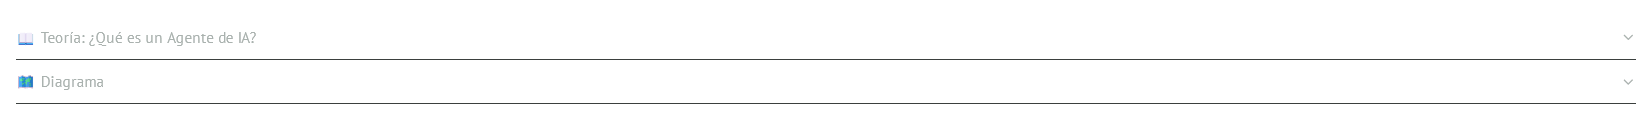

In [ ]:
mo.accordion(
    {
        "📖 Teoría: ¿Qué es un Agente de IA?": mo.md(
            r"""
Imagina un **cerebro dentro de un frasco** 🧠. Es brillante, sabe muchísimo y
razona de maravilla… pero está flotando en líquido, sin ojos, sin manos, sin
forma de tocar el mundo. Eso es exactamente un LLM por sí solo: una máquina que
produce texto. Puede *hablar* de buscar el clima, pero no puede salir a buscarlo.
Un **agente** es lo que le pones alrededor a ese cerebro para darle manos, ojos y
voluntad de actuar.

Concretamente, un agente es un **LLM + herramientas (tools) + un bucle** que
decide, actúa y observa hasta resolver la tarea. Ese bucle tiene nombre: **ReAct**
(Reason + Act), y funciona así, paso a paso:

1. **Razonar** 🤔 — el LLM lee tu petición y decide qué hacer.
2. **Actuar** 🔧 — si le falta información, llama a una herramienta.
3. **Observar** 👁️ — recibe el resultado de esa herramienta.
4. **Repetir** 🔁 — con el nuevo dato, vuelve a razonar; ¿basta o falta más?
5. **Responder** 💬 — cuando ya tiene contexto suficiente, redacta la respuesta.

Veámoslo con un ejemplo. Le preguntas: *"¿qué tiempo hace en Guadalajara?"*. El
cerebro en el frasco **no lo sabe** — el clima de hoy no estaba en sus datos de
entrenamiento. Aquí un chatbot cualquiera alucinaría o se disculparía. El agente,
en cambio, razona "necesito datos frescos", **actúa** llamando a `buscar_en_red`,
**observa** los resultados que vuelven de la web y solo entonces **responde** con
información real y fundamentada. Esa es la diferencia clave: **un chatbot responde
con lo que ya sabe; un agente puede ir a buscar lo que no sabe.**

¿Quién orquesta este baile? Aquí entran dos piezas del ecosistema. **LangGraph**
implementa el bucle como un **grafo de estados**: nodos que representan "pensar",
"usar herramienta", "terminar", y las flechas que deciden a dónde ir después de
cada paso. **LangChain** aporta las abstracciones de alto nivel — las tools, los
tipos de mensajes, la conexión con el modelo — para que no tengas que cablear todo
a mano. Juntos convierten un cerebro pasivo en un trabajador autónomo.

**Dónde verlo en este notebook:** abre el panel **🗺️ Arquitectura Dinámica del
Agente** para ver el grafo real de LangGraph que ejecuta este ciclo; usa el **chat**
para pedirle algo que no pueda saber (como el clima de hoy) y observa cómo sale a
buscarlo; y revisa la tool **`buscar_en_red`** en las celdas de herramientas para
ver el "brazo" que le permite alcanzar la web.
"""
        ),
        "🗺️ Diagrama": mo.mermaid(
            """
flowchart TD
U["👤 Usuario"] --> R{"🧠 Razonar<br/>(el LLM decide)"}
R -->|"necesita datos"| A["🔧 Actuar<br/>(llamar una tool)"]
A --> O["👁️ Observar<br/>(resultado de la tool)"]
O --> R
R -->|"contexto suficiente"| F["💬 Responder"]
F --> U
"""
        ),
    }
)

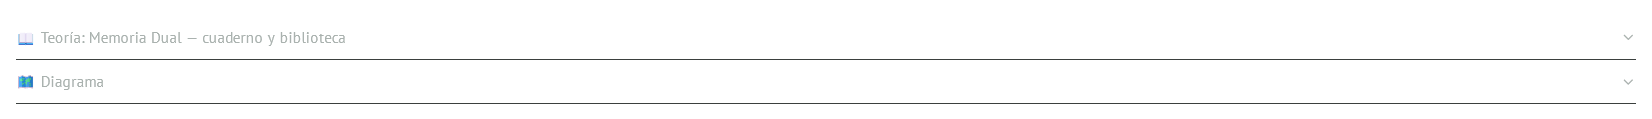

In [ ]:
mo.accordion(
    {
        "📖 Teoría: Memoria Dual — cuaderno y biblioteca": mo.md(
            r"""
Piensa en dos formas de recordar. Tienes un **cuaderno de notas** 📓 que llevas
durante una conversación: apuntas lo que se va diciendo y lo consultas sin salir de
esa charla. Y tienes una **biblioteca personal** 📚 donde guardas lo que quieres
conservar para siempre: la usas hoy, la seguirás usando dentro de un año. Un buen
agente necesita **las dos**, porque tienen trabajos distintos.

El punto de partida incómodo es este: **los LLM son amnésicos**. Cada llamada al
modelo empieza literalmente de cero; no "recuerda" el turno anterior. Toda la
memoria que percibes es en realidad **contexto que alguien vuelve a inyectar** en
cada petición. Si nadie reinyecta, no hay memoria. Por eso construimos capas.

La **Capa 1 (corto plazo)** es el *checkpointer* (`SqliteSaver`): guarda el hilo
turno a turno en disco. Cada sesión tiene su `thread_id` — su propio cuaderno —, y
al cambiar de hilo empiezas con la libreta en blanco. Sirve para "¿qué te dije hace
veinte mensajes?" dentro de la misma charla.

La **Capa 2 (largo plazo)** es el *store* (`AlmacenPersistenteSQLite`): guarda
**hechos duraderos** — tus preferencias, tus proyectos, tus gustos — y persisten
entre **todas** las sesiones. Funciona con *write-through*: mantiene los datos en
RAM para buscar rápido, pero cada escritura baja también a SQLite para sobrevivir a
los reinicios. Y busca de forma **híbrida**, combinando tres estrategias: la
**semántica** (embeddings + similitud coseno) entiende el significado aunque cambies
las palabras; la **keyword** (`LIKE`) atrapa el término exacto que la semántica a
veces pasa por alto; y la **recencia** (`ORDER BY`) prioriza lo más nuevo. Cada una
falla sola — la semántica ignora nombres literales, la keyword no entiende sinónimos,
la recencia olvida lo importante pero viejo — pero **juntas se cubren los huecos**.

La **Capa 3 (reflexión autónoma)** cierra el sistema: después de cada turno, el
modelo de respaldo relee la conversación, **extrae hechos nuevos y los guarda solo**,
sin que tú se lo pidas. Y `@dynamic_prompt` es el pegamento final: **antes** de cada
turno inyecta en el system prompt los recuerdos relevantes, para que el cerebro
amnésico despierte ya sabiendo quién eres.

**Dónde verlo en este notebook:** el **🗄️ Inspector de Memoria a Largo Plazo** te
deja ver y buscar los hechos de la Capa 2; el **🔍 Visor de Inyección de Memoria
Dinámica** te muestra exactamente qué recuerdos se cuelan en el prompt antes de
responder; y las tools **`recordar`**, **`evocar`** y **`olvidar`** son las que
escriben, consultan y borran esa biblioteca personal.
"""
        ),
        "🗺️ Diagrama": mo.mermaid(
            """
flowchart LR
subgraph CP["📓 Corto plazo — el hilo"]
    CK[("SqliteSaver<br/>checkpointer")]
end
subgraph LP["📚 Largo plazo — los hechos"]
    ST[("AlmacenPersistenteSQLite<br/>store + embeddings")]
end
AG["🤖 Agente"] -->|"mensajes del turno"| CK
AG -->|"recordar / evocar / olvidar"| ST
RF["🪞 Reflexión autónoma<br/>(tras cada turno)"] -->|"extrae hechos"| ST
ST -->|"@dynamic_prompt inyecta<br/>recuerdos relevantes"| AG
"""
        ),
    }
)

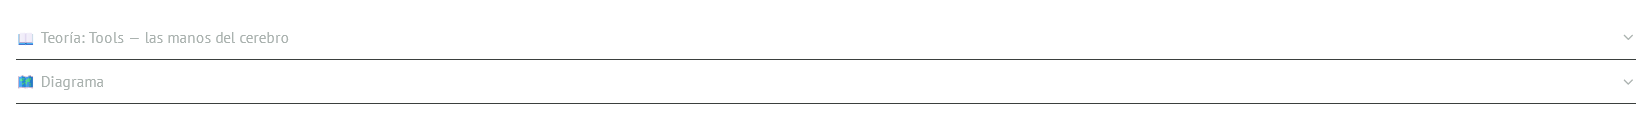

In [ ]:
mo.accordion(
    {
        "📖 Teoría: Tools — las manos del cerebro": mo.md(
            r"""
Si el LLM es el cerebro en el frasco, las **tools son sus manos** 🖐️. Son lo que le
permite tocar el mundo: buscar en la web, guardar un recuerdo, dibujar un gráfico.
Sin ellas, el agente solo piensa; con ellas, actúa.

Técnicamente una tool es **una función de Python normal** con el decorador `@tool`
encima. Pero hay un detalle crucial que sorprende a casi todo el mundo: **el LLM
nunca ejecuta código**. Lo que hace es *emitir una petición* — un `tool_call` en
formato JSON que dice "quiero llamar a `buscar_en_red` con este argumento" — y es un
**ejecutor** aparte quien corre la función Python de verdad. El modelo pide; el
runtime obedece. Esa separación es lo que hace el sistema seguro y depurable.

¿Y cómo sabe el LLM qué herramienta usar y cómo? El contrato son **el docstring +
los type hints**. El modelo lee la **descripción** (el docstring) para decidir
*cuándo* invocar la tool, y lee el **schema de argumentos** (inferido de los type
hints) para saber *cómo* rellenarla. La consecuencia práctica es contundente: **un
docstring malo produce una tool que nunca se usa o se usa mal.** Escribir buenas
descripciones no es cosmética, es programar el criterio del agente.

Cuando la función termina, su resultado no vuelve como un valor cualquiera: regresa
envuelto en un **`ToolMessage`** que el LLM lee en el siguiente paso del ciclo ReAct
— exactamente el "Observar" del Concepto 1.

Este notebook trae un inventario de tools organizado por familias: de **memoria**
(`recordar`, `evocar`, `olvidar`), de **web** (`buscar_en_red`,
`investigar_a_fondo`, `extraer_pagina_web`), de **academia** (`search_arxiv`), de
**plataforma** (`instalar_skill`) y **multimodal** (`generar_grafico`). Cada familia
le da al agente un tipo de "mano" distinto.

Una sutileza elegante para cerrar: cuando algo falla **dentro** de una tool, el error
se devuelve como **texto** (no como una excepción que rompe todo). ¿Por qué? Porque
así el agente **lee el error, entiende qué salió mal y puede autocorregirse** en el
siguiente turno, en lugar de estrellarse.

**Dónde verlo en este notebook:** recorre las **celdas de tools** para leer los
docstrings reales que educan al modelo, y baja hasta el **🛠️ Editor de Herramientas
del Estudiante** al final, donde el editor **compila y valida** tu tool con el
decorador `@tool`. Para que el agente la use de verdad hace falta **reconstruir el
agente** (el mismo patrón de recarga reactiva que usan Skills, Reparto y MCP): hoy el
notebook lo deja como ejercicio.
"""
        ),
        "🗺️ Diagrama": mo.mermaid(
            """
sequenceDiagram
participant U as 👤 Usuario
participant L as 🧠 LLM
participant E as ⚙️ Ejecutor
participant T as 🔧 buscar_en_red()
U->>L: "¿Qué tiempo hace en Guadalajara?"
L->>E: tool_call: buscar_en_red("clima Guadalajara")
E->>T: ejecuta la función Python
T-->>E: resultados de Tavily
E-->>L: ToolMessage con el resultado
L-->>U: respuesta fundamentada en datos
"""
        ),
    }
)

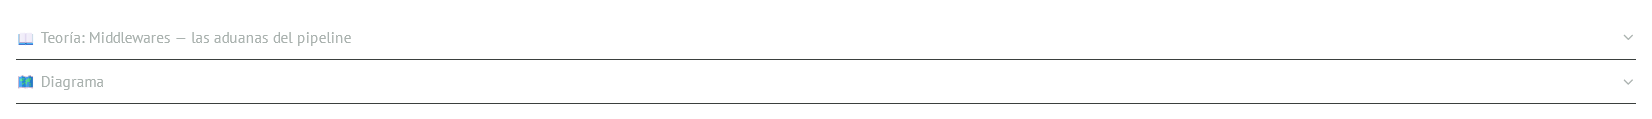

In [ ]:
mo.accordion(
    {
        "📖 Teoría: Middlewares — las aduanas del pipeline": mo.md(
            r"""
Imagina que cada petición al agente es un viajero que cruza varias **aduanas** 🛃
antes de llegar a su destino. En cada frontera, un oficial puede **inspeccionar**,
**modificar** o incluso **detener** el paso. Eso es un middleware: una capa que
envuelve al agente y por la que la petición tiene que pasar en su camino de ida y de
vuelta.

La regla de orden es sencilla: los middlewares **se aplican en el orden de la lista**,
y el **primero de la lista es la capa más externa** — la primera aduana que cruzas al
entrar y la última al salir. Cambiar el orden cambia el comportamiento.

Este notebook apila varias capas, y conviene que sepas el propósito de cada una en una
frase: **memoria dinámica** inyecta tus recuerdos en el prompt; **resumen** (el
automático de deepagents) comprime el histórico cuando crece demasiado; **edición de
contexto** poda resultados de tools para liberar espacio; **humano en el bucle** pausa
y pide tu aprobación antes de acciones críticas; **límites** de modelo/tools ponen
topes para que no se desboque; **reintentos** vuelve a intentar ante fallos
transitorios; **fallback** cambia a un modelo de respaldo si el principal cae;
**selector de tools** filtra qué herramientas ve el modelo; y **PII** protege datos
personales sensibles.

Aquí hay un **gotcha real** que te ahorrará un dolor de cabeza: en este notebook **no
añadimos un `SummarizationMiddleware` manual ni un `TodoListMiddleware`**. ¿Por qué?
Porque **deepagents ya los trae de serie**. Si duplicas el de resumen, obtienes un
`AssertionError`; y la planificación ya la resuelve deepagents con `write_todos`, así
que un TodoList manual sobra. Menos es más cuando el framework ya te lo da.

Lo mejor es que todo esto es **vivo**: el panel de switches **reconstruye el pipeline
en tiempo real** al activar o desactivar capas, y el diagrama Mermaid se redibuja para
reflejar exactamente qué aduanas están abiertas en este momento. Puedes *ver* cómo
cambia la arquitectura mientras juegas con los interruptores.

**Dónde verlo en este notebook:** abre el **⚙️ Panel de Control del Agente** para
encender y apagar middlewares con los switches, mira la lista **"Pipeline activo"**
que enumera las capas vigentes, y contempla el **🗺️ Arquitectura Dinámica del
Agente** para ver el grafo real que resulta de tu configuración.
"""
        ),
        "🗺️ Diagrama": mo.mermaid(
            """
flowchart LR
IN["📨 Petición"] --> M1["🧠 memoria<br/>dinámica"]
M1 --> M2["📄 resumen<br/>(deepagents)"]
M2 --> M3["✂️ edición de<br/>contexto"]
M3 --> M4["🙋 humano en<br/>el bucle"]
M4 --> M5["🛑 límites"]
M5 --> M6["♻️ reintentos<br/>+ fallback"]
M6 --> NU["🤖 LLM + tools"]
NU --> OUT["📬 Respuesta"]
"""
        ),
    }
)

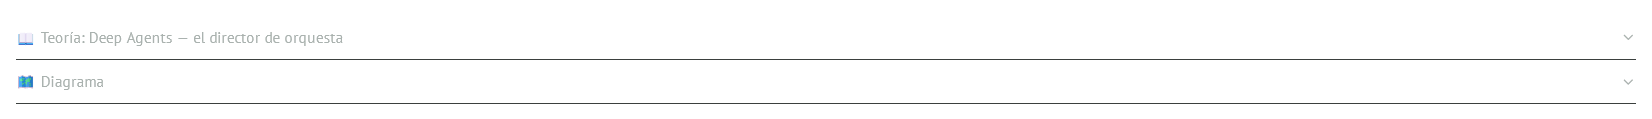

In [ ]:
mo.accordion(
    {
        "📖 Teoría: Deep Agents — el director de orquesta": mo.md(
            r"""
Un agente plano es como un músico talentoso que **improvisa** sobre la marcha: brilla
en piezas cortas, pero en una obra larga pierde el hilo. Un **deep agent** es un
**director de orquesta con partitura** 🎼: no solo toca, sino que **planifica, anota y
delega**. Esa es la promesa de esta arquitectura.

En código, `create_deep_agent()` **envuelve** a `create_agent()` y le añade **cuatro
superpoderes de serie**: **planificación** (la tool `write_todos`), **filesystem**
(`ls` / `read_file` / `write_file` / `edit_file` sobre un backend real),
**subagentes** (la tool `task`, para delegar en personajes con contexto propio) y
**skills** (progressive disclosure: carga instrucciones solo cuando las necesita).

¿Por qué importa la planificación? Porque **los agentes planos fallan en tareas
largas al perder el plan** dentro de una ventana de contexto que se llena y se resume.
El truco del deep agent es **externalizar el plan** a una lista de tareas que vive
*fuera* del contexto del LLM: aunque el modelo olvide, el todo-list recuerda.

El filesystem es igual de potente. `FilesystemBackend(root_dir=...)` hace que el
agente vea **nuestro proyecto real** — no un sandbox de juguete, sino los archivos de
verdad. Como eso es peligroso, existe el switch **Filesystem Protegido**: al activarlo,
`write_file` y `edit_file` quedan bajo `interrupt_on` y **piden tu aprobación** antes
de tocar nada. Poder con freno de mano.

Hay dos cosas que `create_deep_agent()` **añade automáticamente** y conviene tener
presentes: un **`SummarizationMiddleware`** (por eso en el Concepto 4 dijimos que
duplicarlo da `AssertionError`) y un **system prompt de andamiaje** propio. Ese
segundo detalle explica una decisión de diseño de este notebook: nuestro middleware de
memoria **appendea** al prompt en vez de reemplazarlo, para no borrar el andamiaje que
deepagents necesita.

Y lo mejor: nada de esto rompe lo anterior. El `checkpointer` y el `store` se le pasan
**tal cual**, así que **toda la memoria dual del Concepto 2 sigue funcionando debajo**.
Los superpoderes se suman; no sustituyen.

**Dónde verlo en este notebook:** busca la celda **`create_deep_agent`** para ver el
ensamblaje real; activa el switch **📁 Filesystem Protegido** en el Panel de Control y
observa cómo cambia el comportamiento de escritura; y en el **chat** pídele *"escribe
un plan con write_todos"* para ver la planificación integrada en acción.
"""
        ),
        "🗺️ Diagrama": mo.mermaid(
            """
flowchart TD
CDA["create_deep_agent()"] --> P["🗺️ write_todos<br/>planificación integrada"]
CDA --> FS["📁 filesystem<br/>ls · read · write · edit"]
CDA --> TK["🎭 task<br/>delegar en subagentes"]
CDA --> SK["🧩 skills<br/>progressive disclosure"]
CDA --> SUM["📄 Summarization<br/>automático"]
P --> LG["🕸️ Grafo LangGraph resultante"]
FS --> LG
TK --> LG
SK --> LG
SUM --> LG
"""
        ),
    }
)

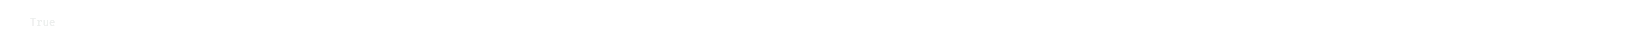

In [ ]:
import os
import sqlite3
import json
import uuid
import datetime
import numpy as np
from pathlib import Path

# ── Utilidades ────────────────────────────────────────────────────────────────────
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing import List, Literal, Optional
import urllib.request
import urllib.parse
import xml.etree.ElementTree as ET
import asyncio

# ── Núcleo LangChain / LangGraph ──────────────────────────────────────────────────
from langchain.tools import tool
from langchain.agents.middleware import (
    dynamic_prompt,
    ContextEditingMiddleware,
    HumanInTheLoopMiddleware,
    ModelCallLimitMiddleware,
    ToolCallLimitMiddleware,
    ToolRetryMiddleware,
    ModelRetryMiddleware,
    ModelFallbackMiddleware,
    LLMToolSelectorMiddleware,
    PIIMiddleware,
)
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import Item, PutOp

# ── Integración NVIDIA (opcional) ────────────────────────────────────────────────
try:
    from langchain_nvidia_ai_endpoints import ChatNVIDIA, NVIDIAEmbeddings

    PAQUETE_NVIDIA = True
except ImportError:
    PAQUETE_NVIDIA = False
    ChatNVIDIA = NVIDIAEmbeddings = None

# ── DeepAgents ────────────────────────────────────────────────────────────────────
from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend

# ── Módulo de soporte local (funciones puras testeadas con pytest) ───────────────
import sys

sys.path.insert(0, str(Path(__file__).parent))
import deep_soporte as ds
import mcp_soporte as ms

# ── Cliente MCP (opcional): si falta el paquete, el agente sigue sin MCP ────────
try:
    from langchain_mcp_adapters.client import MultiServerMCPClient

    ADAPTERS_MCP = True
except ImportError:
    ADAPTERS_MCP = False
    MultiServerMCPClient = None

# Cargar variables de entorno desde .env (NVIDIA_API_KEY, TAVILY_API_KEY…)
load_dotenv()

In [ ]:
PRESENCIA_API_NVIDIA = bool(
    os.environ.get("NVIDIA_API_KEY", "").startswith("nvapi")
)

# ── Modelos NVIDIA NIM ────────────────────────────────────────────────────────────
MODELO_ESTANDAR = os.environ.get(
    "NIM_MODEL", "nvidia/nemotron-3-ultra-550b-a55b"
)
MODELO_RAZONAMIENTO = os.environ.get(
    "NIM_FALLBACK", "nvidia/nemotron-3-nano-omni-30b-a3b-reasoning"
)
MODELO_EMBEDDINGS = os.environ.get("NIM_EMBED", "nvidia/nv-embedqa-e5-v5")

# ── Identidad del usuario y rutas de persistencia ────────────────────────────────
ID_USUARIO = os.environ.get("CEREBRO_USER", "usuario_principal")

DIRECTORIO_MEMORIA = Path(
    os.environ.get("CEREBRO_DIR", Path.home() / ".memoria_cerebro")
)
DIRECTORIO_MEMORIA.mkdir(parents=True, exist_ok=True)

# Ruta absoluta → nunca depende del cwd (causa #1 de "no me guardó nada" en Windows)
RUTA_BD_LARGO_PLAZO = str(
    (DIRECTORIO_MEMORIA / "memorias_largo_plazo.db").resolve()
)
RUTA_BD_CORTO_PLAZO = str(
    (DIRECTORIO_MEMORIA / "hilos_corto_plazo.db").resolve()
)

# ── Raíz del proyecto y directorios del agente profundo ─────────────────────────
RAIZ_PROYECTO = Path(__file__).parent.resolve()
DIR_SKILLS = RAIZ_PROYECTO / "skills"
DIR_SUBAGENTES = RAIZ_PROYECTO / "subagentes"
DIR_ARTEFACTOS = RAIZ_PROYECTO / "artefactos"
for _d in (DIR_SKILLS, DIR_SUBAGENTES, DIR_ARTEFACTOS):
    _d.mkdir(parents=True, exist_ok=True)

# Sembrar ejemplos didácticos la primera vez (idempotente)
ds.sembrar_skill_ejemplo(DIR_SKILLS)
ds.sembrar_subagente_ejemplo(DIR_SUBAGENTES)

# Config MCP declarativa (mismo formato que claude_desktop_config.json)
RUTA_CONFIG_MCP = RAIZ_PROYECTO / "mcp_config.json"
ms.sembrar_config_mcp(RUTA_CONFIG_MCP)

---
## ⚙️ Panel de Control del Agente

Ajusta los parámetros del LLM y activa/desactiva middlewares.
Marimo reconstruye el agente y el diagrama de arquitectura **en tiempo real**
cada vez que cambias un valor — sin necesidad de reiniciar nada.

In [ ]:
ui_temperatura = mo.ui.slider(
    start=0.0,
    stop=1.0,
    step=0.05,
    value=0.6,
    label="**Temperatura** — Creatividad / aleatoriedad del modelo",
)
ui_top_p = mo.ui.slider(
    start=0.1,
    stop=1.0,
    step=0.05,
    value=0.95,
    label="**Top-P** — Diversidad del vocabulario (nucleus sampling)",
)
ui_max_tokens = mo.ui.slider(
    start=256,
    stop=65536,
    step=256,
    value=16384,
    label="**Máximo de tokens** — Longitud máxima de la respuesta",
)
ui_reason_budget = mo.ui.slider(
    start=1024,
    stop=32768,
    step=256,
    value=8192,
    label="**Tokens de pensamiento** — Presupuesto para razonamiento interno (CoT)",
)
ui_razonamiento = mo.ui.switch(
    value=True,
    label="🧠 **Habilitar Razonamiento (Chain-of-Thought)** — Usa el modelo de razonamiento",
)

In [ ]:
menu_middlewares = mo.ui.dictionary(
    {
        "resumen_conversacion": mo.ui.switch(
            value=True,
            label="📄 **Resumen Automático** (informativo — deepagents lo añade "
            "siempre) — Condensa historiales largos para no agotar el contexto",
        ),
        "modelo_respaldo": mo.ui.switch(
            value=True,
            label="🔄 **Modelo de Respaldo (Fallback)** — Redirige al modelo secundario si el principal falla",
        ),
        "edicion_contexto": mo.ui.switch(
            value=True,
            label="✂️ **Edición de Contexto** — Poda resultados viejos de herramientas para liberar tokens",
        ),
        "humano_en_bucle": mo.ui.switch(
            value=False,
            label="🙋 **Humano en el Bucle** — Pausa y pide aprobación antes de acciones críticas",
        ),
        "limite_llamadas_modelo": mo.ui.switch(
            value=True,
            label="🛑 **Límite: Llamadas al Modelo** — Previene bucles infinitos (máx. 60/hilo, 25/run)",
        ),
        "limite_llamadas_herramienta": mo.ui.switch(
            value=True,
            label="🛑 **Límite: Herramientas** — Tope de seguridad en invocaciones de tools (máx. 80/hilo)",
        ),
        "reintento_herramienta": mo.ui.switch(
            value=True,
            label="♻️ **Reintento de Herramienta** — Reintenta tools que lanzan excepción (máx. 2 veces)",
        ),
        "reintento_modelo": mo.ui.switch(
            value=True,
            label="♻️ **Reintento del Modelo** — Reintenta el LLM ante errores de red o timeouts",
        ),
        "filesystem_protegido": mo.ui.switch(
            value=False,
            label="📁 **Filesystem Protegido** — Pide aprobación antes de write_file / edit_file",
        ),
        "selector_herramientas": mo.ui.switch(
            value=False,
            label="🔍 **Selector Dinámico de Herramientas** — Filtra tools por relevancia (útil con >10 tools)",
        ),
        "censura_datos_personales": mo.ui.switch(
            value=False,
            label="🔒 **Censura PII** — Detecta y enmascara email, URL, IP, teléfono y NSS",
        ),
    }
)

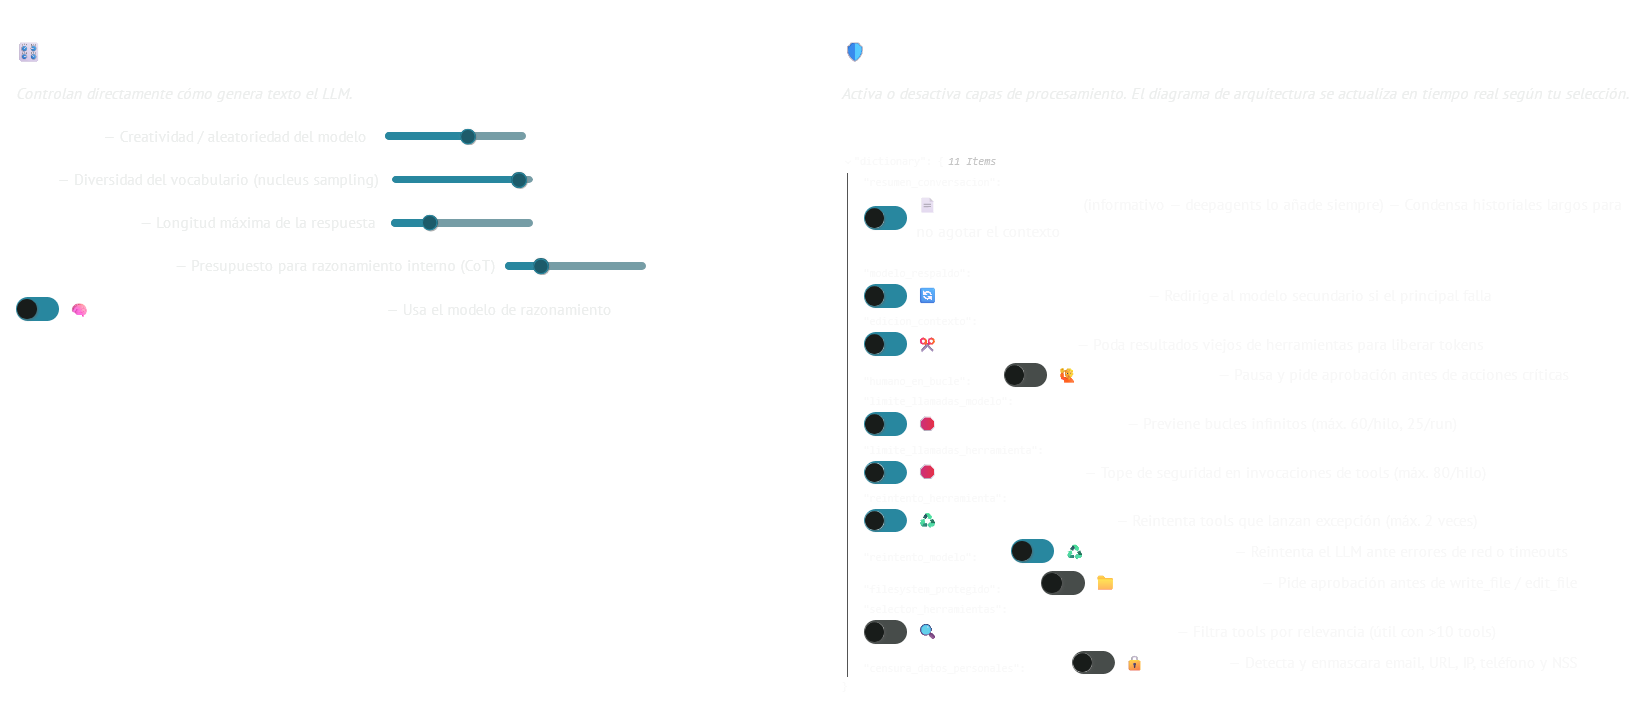

In [ ]:
_panel_llm = mo.md(f"""
### 🎛️ Parámetros del Motor de Inferencia
*Controlan directamente cómo genera texto el LLM.*

{ui_temperatura}

{ui_top_p}

{ui_max_tokens}

{ui_reason_budget}

{ui_razonamiento}
""")

_panel_mw = mo.md(f"""
### 🛡️ Pipeline de Middlewares
*Activa o desactiva capas de procesamiento. El diagrama de arquitectura
se actualiza en tiempo real según tu selección.*

{menu_middlewares}
""")

mo.hstack([_panel_llm, _panel_mw], widths=[1, 1], gap=2)

In [ ]:
class AlmacenPersistenteSQLite(InMemoryStore):
    """Extiende InMemoryStore con persistencia transparente en SQLite.

    Hereda toda la lógica de búsqueda semántica (coseno, ANN) de InMemoryStore
    y añade write-through a disco para que los datos sobrevivan reinicios.
    """

    def __init__(self, ruta_bd: str, *, index=None):
        super().__init__(index=index)
        self._ruta_bd = str(ruta_bd)
        self._conexion = sqlite3.connect(
            self._ruta_bd, check_same_thread=False
        )
        self._conexion.execute("PRAGMA journal_mode=WAL;")
        self._inicializar_esquema()
        self._cargar_datos()

    def _inicializar_esquema(self):
        self._conexion.executescript("""
            CREATE TABLE IF NOT EXISTS store_items(
                namespace      TEXT,
                clave          TEXT,
                valor          TEXT,
                creado_el      TEXT,
                actualizado_el TEXT,
                PRIMARY KEY(namespace, clave)
            );
            CREATE TABLE IF NOT EXISTS store_vectores(
                namespace TEXT,
                clave     TEXT,
                ruta      TEXT,
                vector    BLOB,
                PRIMARY KEY(namespace, clave, ruta)
            );
        """)
        self._conexion.commit()

    @staticmethod
    def _ns_a_str(ns: tuple) -> str:
        return json.dumps(list(ns))

    @staticmethod
    def _str_a_ns(s: str) -> tuple:
        return tuple(json.loads(s))

    def _cargar_datos(self):
        """Carga ítems y vectores desde SQLite al InMemoryStore en RAM al iniciar."""
        for (
            ns_s,
            clave,
            valor,
            creado,
            actualizado,
        ) in self._conexion.execute(
            "SELECT namespace,clave,valor,creado_el,actualizado_el FROM store_items"
        ):
            ns = self._str_a_ns(ns_s)
            self._data[ns][clave] = Item(
                value=json.loads(valor),
                key=clave,
                namespace=ns,
                created_at=creado,
                updated_at=actualizado,
            )
        for ns_s, clave, ruta, blob in self._conexion.execute(
            "SELECT namespace,clave,ruta,vector FROM store_vectores"
        ):
            ns = self._str_a_ns(ns_s)
            self._vectors[ns][clave][ruta] = np.frombuffer(
                blob, dtype=np.float32
            ).tolist()

    def _persistir(self, operaciones):
        """Sincroniza a SQLite las operaciones ya aplicadas en RAM."""
        c = self._conexion
        for op in operaciones:
            if not isinstance(op, PutOp):
                continue
            ns_s = self._ns_a_str(op.namespace)

            if op.value is None:  # borrado
                c.execute(
                    "DELETE FROM store_items WHERE namespace=? AND clave=?",
                    (ns_s, op.key),
                )
                c.execute(
                    "DELETE FROM store_vectores WHERE namespace=? AND clave=?",
                    (ns_s, op.key),
                )
                continue

            item = self._data[op.namespace][op.key]
            c.execute(
                "INSERT OR REPLACE INTO store_items VALUES(?,?,?,?,?)",
                (
                    ns_s,
                    op.key,
                    json.dumps(item.value),
                    str(item.created_at),
                    str(item.updated_at),
                ),
            )
            c.execute(
                "DELETE FROM store_vectores WHERE namespace=? AND clave=?",
                (ns_s, op.key),
            )
            for ruta, vector in (
                self._vectors.get(op.namespace, {}).get(op.key, {}).items()
            ):
                c.execute(
                    "INSERT OR REPLACE INTO store_vectores VALUES(?,?,?,?)",
                    (
                        ns_s,
                        op.key,
                        ruta,
                        np.asarray(vector, dtype=np.float32).tobytes(),
                    ),
                )
        c.commit()

    def batch(self, ops):
        ops = list(ops)
        res = super().batch(ops)  # aplica en RAM + genera embeddings
        self._persistir(ops)  # sincroniza a disco
        return res

    async def abatch(self, ops):
        ops = list(ops)
        res = await super().abatch(ops)
        self._persistir(ops)
        return res

    # ── Métodos de consulta adicionales (SQL directo, sin embeddings) ────────────

    def recientes(self, namespace: tuple, limite: int = 5) -> list[dict]:
        """Devuelve los `limite` ítems más recientemente actualizados."""
        filas = self._conexion.execute(
            "SELECT valor FROM store_items "
            "WHERE namespace=? ORDER BY actualizado_el DESC LIMIT ?",
            (self._ns_a_str(namespace), limite),
        ).fetchall()
        return [json.loads(v) for (v,) in filas]

    def palabra_clave(
        self, namespace: tuple, termino: str, limite: int = 10
    ) -> list[dict]:
        """Búsqueda LIKE sobre el valor JSON serializado (case-insensitive)."""
        filas = self._conexion.execute(
            "SELECT valor FROM store_items "
            "WHERE namespace=? AND lower(valor) LIKE ? "
            "ORDER BY actualizado_el DESC LIMIT ?",
            (self._ns_a_str(namespace), f"%{termino.lower()}%", limite),
        ).fetchall()
        return [json.loads(v) for (v,) in filas]

In [ ]:
ESPACIO_MEMORIA = ("memorias", ID_USUARIO)
incrustador = None
DIMENSIONES_EMB = None
semantica_activa = False

if PAQUETE_NVIDIA and PRESENCIA_API_NVIDIA:
    try:
        incrustador = NVIDIAEmbeddings(
            model=MODELO_EMBEDDINGS, truncate="END"
        )
        DIMENSIONES_EMB = len(
            incrustador.embed_query("sonda de dimensiones")
        )
        semantica_activa = True
    except Exception:
        semantica_activa = False

configuracion_indice = (
    {"dims": DIMENSIONES_EMB, "embed": incrustador, "fields": ["text"]}
    if semantica_activa
    else None
)
almacen_memoria = AlmacenPersistenteSQLite(
    RUTA_BD_LARGO_PLAZO, index=configuracion_indice
)

In [ ]:
_conexion_cp = sqlite3.connect(RUTA_BD_CORTO_PLAZO, check_same_thread=False)
gestor_puntos_control = SqliteSaver(_conexion_cp)
gestor_puntos_control.setup()

In [ ]:
llm_principal = llm_respaldo = llm_razonamiento_obj = None
nombre_modelo_activo = (
    MODELO_RAZONAMIENTO if ui_razonamiento.value else MODELO_ESTANDAR
)

if PAQUETE_NVIDIA and PRESENCIA_API_NVIDIA:
    _params = {
        "temperature": ui_temperatura.value,
        "top_p": ui_top_p.value,
        "max_tokens": ui_max_tokens.value,
    }
    _thinking = {"enable_thinking": ui_razonamiento.value}

    llm_principal = ChatNVIDIA(
        model=nombre_modelo_activo,
        **_params,
        chat_template_kwargs=_thinking,
    )
    # El respaldo siempre usa el modelo estándar (más estable)
    llm_respaldo = ChatNVIDIA(
        model=MODELO_ESTANDAR,
        **_params,
        chat_template_kwargs=_thinking,
    )
    # Objeto dedicado para el alias de subagente 'razonamiento': a
    # diferencia de llm_principal (que sigue el switch de CoT del
    # director), este SIEMPRE usa MODELO_RAZONAMIENTO.
    llm_razonamiento_obj = ChatNVIDIA(
        model=MODELO_RAZONAMIENTO,
        **_params,
        chat_template_kwargs=_thinking,
    )
llm_estandar_obj = (
    llm_respaldo  # alias claro para el resolvedor de subagentes
)

In [ ]:
def ultimo_texto_usuario(mensajes: list) -> str:
    """Extrae el último mensaje del usuario de la lista del agente."""
    for m in reversed(mensajes):
        if m.__class__.__name__ == "HumanMessage":
            return (
                m.content if isinstance(m.content, str) else str(m.content)
            )
    return ""

def mezclar_recuerdos(
    consulta: str, k_semantica: int = 3, k_recientes: int = 2
) -> list[str]:
    """Recuperación híbrida: semántica + recencia, deduplicada, orden estable."""
    textos: list[str] = []
    vistos: set[str] = set()

    def agregar(t: str):
        if t and t not in vistos:
            vistos.add(t)
            textos.append(t)

    if semantica_activa:
        try:
            for item in almacen_memoria.search(
                ESPACIO_MEMORIA, query=consulta, limit=k_semantica
            ):
                agregar(item.value.get("text", ""))
        except Exception:
            pass  # falla graciosamente

    for v in almacen_memoria.recientes(ESPACIO_MEMORIA, k_recientes):
        agregar(v.get("text", ""))

    return textos

In [ ]:
@tool
def recordar(texto: str, categoria: str = "general") -> str:
    """Almacena un recuerdo DURADERO sobre el usuario en la base de datos de largo plazo.
    Úsalo cuando aprendas algo relevante que deba persistir en futuras conversaciones:
    preferencias, proyectos actuales, restricciones, metas o decisiones importantes.
    `categoria` agrupa el recuerdo (ej. 'preferencia', 'proyecto', 'hecho', 'meta')."""
    clave = uuid.uuid4().hex[:12]
    almacen_memoria.put(
        ESPACIO_MEMORIA,
        clave,
        {
            "text": texto,
            "kind": categoria,
            "ts": datetime.datetime.now().isoformat(timespec="seconds"),
        },
    )
    return f"🔒 Recuerdo sellado [{categoria}]: {texto}"

@tool
def evocar(consulta: str, modo: str = "semantica", limite: int = 5) -> str:
    """Busca recuerdos en la memoria a largo plazo del usuario.
    · modo='semantica'     → búsqueda por similitud semántica (requiere NVIDIA_API_KEY).
    · modo='palabra_clave' → coincidencia textual exacta (siempre disponible).
    · modo='reciente'      → los N recuerdos más recientemente guardados.
    Usa 'semantica' por defecto; cae a 'reciente' si el embedding no está disponible."""
    if modo == "reciente":
        valores = almacen_memoria.recientes(ESPACIO_MEMORIA, limite)
    elif modo == "palabra_clave":
        valores = almacen_memoria.palabra_clave(
            ESPACIO_MEMORIA, consulta, limite
        )
    else:
        if not semantica_activa:
            return (
                "(Búsqueda semántica desactivada: falta NVIDIA_API_KEY. "
                "Prueba modo='palabra_clave' o modo='reciente'.)"
            )
        valores = [
            item.value
            for item in almacen_memoria.search(
                ESPACIO_MEMORIA, query=consulta, limit=limite
            )
        ]

    if not valores:
        return "No encontré recuerdos relevantes para esa consulta."
    return "\n".join(
        f"• [{v.get('kind', '?')}] {v.get('text', '')} ({v.get('ts', '')})"
        for v in valores
    )

@tool
def olvidar(consulta: str) -> str:
    """Elimina el recuerdo que mejor coincida con `consulta`.
    Úsalo cuando el usuario pida explícitamente olvidar algo,
    o cuando detectes que un hecho guardado ya es incorrecto o desactualizado."""
    if not semantica_activa:
        coincidencias = almacen_memoria.palabra_clave(
            ESPACIO_MEMORIA, consulta, 1
        )
        if not coincidencias:
            return "No encontré ningún recuerdo que coincida."
        for clave, item in list(
            almacen_memoria._data.get(ESPACIO_MEMORIA, {}).items()
        ):
            if item.value.get("text") == coincidencias[0].get("text"):
                almacen_memoria.delete(ESPACIO_MEMORIA, clave)
                return f"🗑️ Olvidado: {coincidencias[0].get('text', '')}"
        return "No pude localizar la clave del recuerdo para eliminarlo."

    resultados = almacen_memoria.search(
        ESPACIO_MEMORIA, query=consulta, limit=1
    )
    if not resultados:
        return "No encontré ningún recuerdo que coincida."
    almacen_memoria.delete(ESPACIO_MEMORIA, resultados[0].key)
    return f"🗑️ Olvidado: {resultados[0].value.get('text', '')}"

In [ ]:
@tool
def buscar_en_red(consulta: str) -> str:
    """Realiza una búsqueda rápida en internet usando Tavily.
    Devuelve hasta 5 resultados relevantes con título, URL y fragmento.
    Úsalo para preguntas factuales actuales que no estén en tu conocimiento base."""
    try:
        from tavily import TavilyClient

        cliente = TavilyClient(os.getenv("TAVILY_API_KEY"))
        return str(cliente.search(consulta, max_results=5, language="es"))
    except Exception as e:
        return f"Error en búsqueda web: {e}"

@tool
def investigar_a_fondo(consulta: str) -> str:
    """Investigación profunda y multi-fuente usando Tavily Research.
    Más lenta que buscar_en_red pero produce análisis más completos.
    Úsala para temas complejos que requieren síntesis de múltiples fuentes."""
    try:
        from tavily import TavilyClient

        cliente = TavilyClient(os.getenv("TAVILY_API_KEY"))
        return str(cliente.research(consulta))
    except Exception as e:
        return f"Error en investigación: {e}"

@tool
def extraer_pagina_web(url: str) -> str:
    """Extrae el contenido textual de una página web específica usando Tavily Extract.
    Úsalo cuando el usuario proporcione una URL y quiera que analices su contenido."""
    try:
        from tavily import TavilyClient

        cliente = TavilyClient(os.getenv("TAVILY_API_KEY"))
        return str(cliente.extract(url))
    except Exception as e:
        return f"Error al extraer página: {e}"

@tool
def search_arxiv(query: str, max_results: int = 3) -> str:
    """
    Searches the arXiv database for scientific and academic papers.
    Use this tool to find research papers, authors, or abstracts.

    Args:
        query: The search term (e.g., 'machine learning', 'quantum physics').
        max_results: The maximum number of papers to return.
    """
    # Format the URL with the query
    safe_query = urllib.parse.quote(query)
    url = f"http://export.arxiv.org/api/query?search_query=all:{safe_query}&max_results={max_results}"

    try:
        with urllib.request.urlopen(url) as response:
            root = ET.fromstring(response.read())
            ns = {"atom": "http://www.w3.org/2005/Atom"}

            papers = []
            for entry in root.findall("atom:entry", ns):
                title = (
                    entry.find("atom:title", ns)
                    .text.replace("\n", " ")
                    .strip()
                )
                summary = (
                    entry.find("atom:summary", ns)
                    .text.replace("\n", " ")
                    .strip()
                )

                # We return a simple formatted string for the LLM to read
                papers.append(
                    f"Title: {title}\nSummary: {summary[:200]}...\n---"
                )

            return (
                "\n".join(papers)
                if papers
                else "No papers found for this query."
            )

    except Exception as e:
        return f"Tool Error: {str(e)}"

@tool
def instalar_skill(fuente: str, nombre: str = "") -> str:
    """Instala una skill del marketplace de Agent Skills en ./skills/.
    `fuente` puede ser: un nombre corto (se busca en anthropics/skills y
    langchain-ai/langchain-skills), una URL github.com/.../tree/<rama>/<ruta>,
    o una URL raw a un SKILL.md. `nombre` renombra la carpeta destino (opcional).
    Tras instalar, avisa al usuario que pulse 'Recargar' en el Panel de Skills:
    eso reconstruye el agente automáticamente para que la skill quede disponible."""
    try:
        return ds.instalar_skill_desde_fuente(
            fuente, nombre or None, DIR_SKILLS
        )
    except Exception as e:
        return f"❌ Error instalando skill: {e}"

@tool
def generar_grafico(
    datos_json: str,
    tipo: str = "barras",
    eje_x: str = "x",
    eje_y: str = "y",
    titulo: str = "Gráfico",
) -> str:
    """Genera un gráfico PNG en ./artefactos/ a partir de datos tabulares.
    `datos_json`: lista JSON de objetos, ej. '[{"x": "a", "y": 3}, ...]'.
    `tipo`: 'barras' | 'lineas' | 'puntos'. `eje_x`/`eje_y`: columnas a usar.
    Devuelve la ruta del PNG generado (aparece en la Galería y en el chat)."""
    import altair as alt
    import polars as pl

    try:
        df = pl.DataFrame(json.loads(datos_json))
        marcas = {
            "barras": "mark_bar",
            "lineas": "mark_line",
            "puntos": "mark_point",
        }
        metodo_marca = marcas.get(tipo, "mark_bar")
        grafico = getattr(
            alt.Chart(df, title=titulo), metodo_marca
        )().encode(x=eje_x, y=eje_y)
        nombre_archivo = (
            f"grafico_{datetime.datetime.now():%Y%m%d_%H%M%S}"
            f"_{uuid.uuid4().hex[:6]}.png"
        )
        ruta = DIR_ARTEFACTOS / nombre_archivo
        grafico.save(str(ruta))  # requiere vl-convert (ya en deps)
        return f"📊 Gráfico guardado en artefactos/{nombre_archivo}"
    except Exception as e:
        return f"❌ Error generando gráfico: {e}"

herramientas_totales = [
    recordar,
    evocar,
    olvidar,
    buscar_en_red,
    investigar_a_fondo,
    extraer_pagina_web,
    search_arxiv,
    instalar_skill,
    generar_grafico,
]
# Registro nombre→tool: lo usan el constructor de subagentes y su cargador
registro_tools = {t.name: t for t in herramientas_totales}

In [ ]:
PERSONAJE_BASE = (
    "Eres el Agente Profundo: un asistente lúcido, analítico, con memoria "
    "persistente, skills instalables y un reparto de subagentes a tu cargo. "
    "Hablas en el idioma del usuario, tono directo pero cálido. "
    "Cuando aprendas algo nuevo y duradero sobre el usuario, llama a `recordar`. "
    "Delega en tus subagentes (tool `task`) cuando su description encaje con la tarea."
)

@dynamic_prompt
def inyectar_memoria_dinamica(peticion) -> str:
    """APPENDEA recuerdos al system prompt existente.

    ⚠️ Clave con DeepAgents: el prompt entrante ya contiene el andamiaje
    (planning, filesystem, task, skills). Reemplazarlo lo rompería;
    por eso concatenamos en vez de sustituir.
    """
    prompt_existente = peticion.system_prompt or ""
    consulta = ultimo_texto_usuario(peticion.messages) or ID_USUARIO
    recuerdos = mezclar_recuerdos(consulta)

    if recuerdos:
        bloque = "\n".join(f"  - {t}" for t in recuerdos)
        seccion = (
            f"\n\n## Lo que recuerdas de {ID_USUARIO} (memoria persistente):\n"
            f"{bloque}\n\n"
            "Usa estos recuerdos con naturalidad, sin anunciarlos. "
            "Si detectas información desactualizada, usa `olvidar` + `recordar`."
        )
    else:
        seccion = (
            f"\n\nAún no tienes recuerdos de {ID_USUARIO}. "
            "Cuando aprendas algo duradero, llama a `recordar`."
        )
    return prompt_existente + seccion

In [ ]:
middlewares_activos = [inyectar_memoria_dinamica]
middlewares_nombres = ["inyectar_memoria_dinamica"]
opciones = menu_middlewares.value

if llm_principal is not None:
    # create_deep_agent() añade su propio SummarizationMiddleware de forma
    # INCONDICIONAL (deepagents.graph.create_summarization_middleware),
    # sin importar el switch. Un segundo aquí colisiona por nombre de
    # clase y create_agent() lanza AssertionError("Please remove
    # duplicate middleware instances."). Por eso se refleja siempre en la
    # lista — el switch de abajo es solo informativo, no lo controla.
    middlewares_nombres.append(
        "SummarizationMiddleware (provisto automáticamente por deepagents)"
    )

    if opciones["edicion_contexto"]:
        middlewares_activos.append(ContextEditingMiddleware())
        middlewares_nombres.append("ContextEditingMiddleware")

    if opciones["humano_en_bucle"]:
        # NOTA: Desactívalo si usas la UI de chat de Marimo; no puede reanudar
        # un grafo suspendido sin lógica adicional de interrupción.
        middlewares_activos.append(
            HumanInTheLoopMiddleware(
                interrupt_on={
                    "recordar": True,
                    "olvidar": {"allowed_decisions": ["approve", "reject"]},
                    "buscar_en_red": {
                        "allowed_decisions": ["approve", "reject"]
                    },
                    "investigar_a_fondo": {
                        "allowed_decisions": ["approve", "reject"]
                    },
                    "extraer_pagina_web": {
                        "allowed_decisions": ["approve", "reject"]
                    },
                },
                description_prefix="⏸️ Aprobación requerida",
            )
        )
        middlewares_nombres.append("HumanInTheLoopMiddleware")

    if opciones["limite_llamadas_modelo"]:
        middlewares_activos.append(
            ModelCallLimitMiddleware(thread_limit=60, run_limit=25)
        )
        middlewares_nombres.append(
            "ModelCallLimitMiddleware(hilo=60, run=25)"
        )

    if opciones["limite_llamadas_herramienta"]:
        middlewares_activos.append(ToolCallLimitMiddleware(thread_limit=80))
        middlewares_nombres.append("ToolCallLimitMiddleware(hilo=80)")

    if opciones["reintento_herramienta"]:
        middlewares_activos.append(ToolRetryMiddleware(max_retries=2))
        middlewares_nombres.append("ToolRetryMiddleware(max=2)")

    if opciones["reintento_modelo"]:
        middlewares_activos.append(ModelRetryMiddleware(max_retries=2))
        middlewares_nombres.append("ModelRetryMiddleware(max=2)")

    if opciones["modelo_respaldo"] and llm_respaldo is not None:
        middlewares_activos.append(ModelFallbackMiddleware(llm_respaldo))
        middlewares_nombres.append("ModelFallbackMiddleware")

    if opciones["selector_herramientas"]:
        middlewares_activos.append(
            LLMToolSelectorMiddleware(model=llm_principal, max_tools=3)
        )
        middlewares_nombres.append("LLMToolSelectorMiddleware(max=3)")

    if opciones["censura_datos_personales"]:
        middlewares_activos.append(
            PIIMiddleware(
                "email",
                strategy="redact",
                apply_to_tool_results=True,
                apply_to_input=True,
            )
        )
        middlewares_activos.append(PIIMiddleware("url", strategy="redact"))
        middlewares_activos.append(PIIMiddleware("ip", strategy="mask"))
        middlewares_activos.append(
            PIIMiddleware(
                "phone",
                detector=[r"[0-9]{3}-[0-9]{3}-[0-9]{4}", r"[0-9]{10}"],
                strategy="mask",
                apply_to_input=True,
                apply_to_tool_results=True,
            )
        )
        middlewares_activos.append(
            PIIMiddleware(
                "ssn",
                detector=[r"\d{3}-\d{2}-\d{4}"],
                strategy="mask",
            )
        )
        middlewares_nombres.append("PIIMiddleware(email,url,ip,phone,ssn)")

In [ ]:
obtener_version_reparto, marcar_version_reparto = mo.state(0)

def cargar_reparto():
    """Lee ./subagentes/*.md y resuelve alias de modelo a objetos LLM."""
    crudos, avisos = ds.cargar_subagentes(DIR_SUBAGENTES, registro_tools)
    subagentes = []
    for sub in crudos:
        sub = dict(sub)
        alias = sub.pop("model_alias", None)
        if alias == "estandar":
            if llm_estandar_obj is not None:
                sub["model"] = llm_estandar_obj
        elif alias == "razonamiento":
            if llm_razonamiento_obj is not None:
                sub["model"] = llm_razonamiento_obj
        elif alias:
            avisos.append(
                f"⚠️ '{sub['name']}': modelo desconocido '{alias}' — "
                "hereda del director"
            )
        # sin alias → hereda el modelo del agente principal
        subagentes.append(sub)
    return subagentes, avisos

In [ ]:
# Dependencia reactiva: "Recargar" en el Panel MCP relanza esta celda
_ = obtener_version_mcp()

_servidores, avisos_mcp = ms.cargar_config_mcp(RUTA_CONFIG_MCP)
_conexiones = ms.normalizar_conexiones(_servidores, sys.executable, RAIZ_PROYECTO)

tools_mcp = []
estado_mcp = {}

for _nombre, _cfg_crudo in _servidores.items():
    if _nombre in _conexiones:
        continue
    if isinstance(_cfg_crudo, dict):
        estado_mcp[_nombre] = {
            "estado": "⚪ deshabilitado",
            "tools": [],
            "detalle": "enabled: false en mcp_config.json",
        }
    else:
        estado_mcp[_nombre] = {
            "estado": "🔴 config inválida",
            "tools": [],
            "detalle": "la config debe ser un objeto JSON {clave: valor}",
        }

if _conexiones and not ADAPTERS_MCP:
    avisos_mcp.append(
        "⚠️ langchain-mcp-adapters no está instalado — servidores MCP ignorados."
    )
elif _conexiones:
    # Un cliente POR SERVIDOR: si uno falla (comando roto, red caída),
    # los demás siguen funcionando y el error queda visible en el panel.
    # tool_name_prefix=True renombra cada tool a "<servidor>_<tool>"
    # (ej. laboratorio_consultar_glosario) para evitar colisiones entre servidores.
    for _nombre, _conexion in _conexiones.items():
        try:
            _cliente = MultiServerMCPClient(
                {_nombre: _conexion}, tool_name_prefix=True
            )
            _tools = await asyncio.wait_for(
                _cliente.get_tools(), timeout=15
            )
            tools_mcp.extend(_tools)
            estado_mcp[_nombre] = {
                "estado": f"🟢 {len(_tools)} tools",
                "tools": [_t.name for _t in _tools],
                "detalle": "",
            }
        except Exception as _e:
            estado_mcp[_nombre] = {
                "estado": "🔴 error",
                "tools": [],
                "detalle": f"{type(_e).__name__}: {_e}"[:300],
            }

In [ ]:
_ = (
    obtener_version_reparto()
)  # dependencia reactiva: recarga al guardar personajes
_ = (
    obtener_version_skills()
)  # dependencia reactiva: recarga al instalar/recargar skills
subagentes_cargados, avisos_subagentes = cargar_reparto()

agente_cerebro = None
if llm_principal is not None:
    _interrupciones_fs = (
        {"write_file": True, "edit_file": True}
        if menu_middlewares.value["filesystem_protegido"]
        else None
    )
    agente_cerebro = create_deep_agent(
        model=llm_principal,
        system_prompt=PERSONAJE_BASE,
        tools=herramientas_totales + tools_mcp,
        middleware=middlewares_activos,
        subagents=subagentes_cargados,
        backend=FilesystemBackend(root_dir=str(RAIZ_PROYECTO)),
        skills=["skills/"],
        interrupt_on=_interrupciones_fs,
        checkpointer=gestor_puntos_control,
        store=almacen_memoria,
    )

ID_HILO = "sesion-" + uuid.uuid4().hex[:8]

C:\Users\BiomedicLJZ\AppData\Local\Temp\marimo_31612\__marimo__cell_ZBYS_.py:22: LangChainDeprecationWarning: `FilesystemBackend` `virtual_mode` default will change in deepagents==0.6.0; please specify `virtual_mode` explicitly. Note: `virtual_mode` is for virtual path semantics (e.g., `CompositeBackend` routing) and optional path-based guardrails; it does not provide sandboxing or process isolation. Security note: leaving `virtual_mode=False` allows absolute paths and `'..'` to bypass `root_dir`. Consult the API reference for details.
  backend=FilesystemBackend(root_dir=str(RAIZ_PROYECTO)),


In [ ]:
if agente_cerebro is not None:
    arquitectura_mermaid = agente_cerebro.get_graph().draw_mermaid()
    # Mermaid usa [] para nodos; escapar evita conflictos de parseo
    arquitectura_mermaid = arquitectura_mermaid.replace("[", "_").replace(
        "]", "_"
    )
else:
    arquitectura_mermaid = (
        "graph TD\n"
        "    A(⚠️ Agente Inactivo) --> B(Falta NVIDIA_API_KEY)\n"
        "    B --> C(Configura tu .env para activar el agente)"
    )

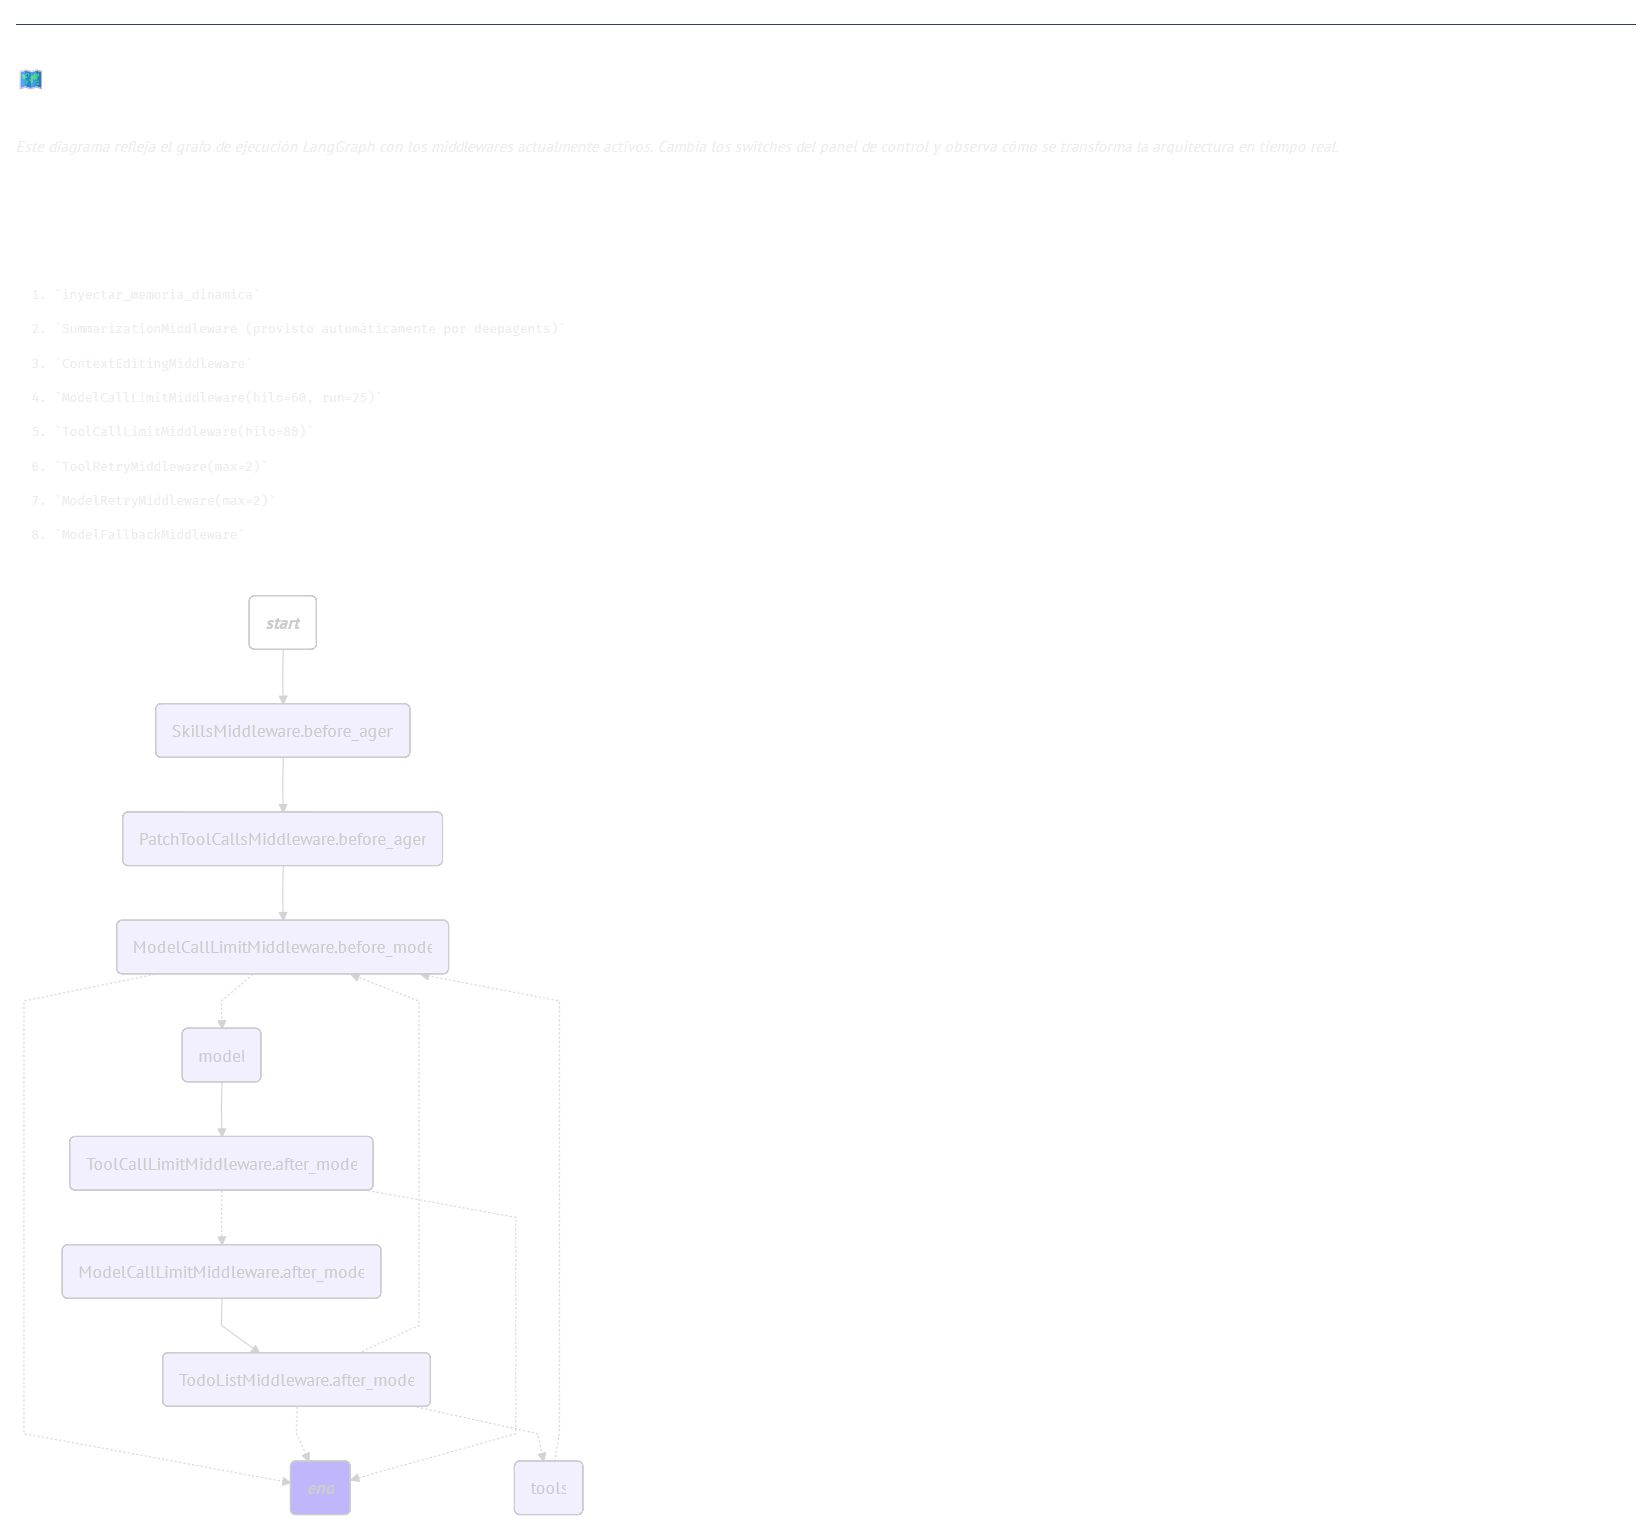

In [ ]:
_lista_mw_arch = "\n".join(
    f"  {i + 1}. `{n}`" for i, n in enumerate(middlewares_nombres)
)

mo.vstack(
    [
        mo.md(f"""
---
## 🗺️ Arquitectura Dinámica del Agente

*Este diagrama refleja el grafo de ejecución LangGraph con los middlewares
actualmente activos. Cambia los switches del panel de control y observa
cómo se transforma la arquitectura en tiempo real.*

**Pipeline activo ({len(middlewares_nombres)} capas):**
{_lista_mw_arch}
"""),
        mo.mermaid(arquitectura_mermaid),
    ]
)

In [ ]:
def render_artefacto(ruta):
    """Convierte un archivo de ./artefactos en el componente Marimo adecuado."""
    categoria = ds.clasificar_artefacto(ruta)
    try:
        if categoria == "imagen":
            return mo.image(str(ruta))
        if categoria == "pdf":
            return mo.pdf(src=str(ruta))
        if categoria == "video":
            return mo.video(str(ruta))
        if categoria == "audio":
            return mo.audio(str(ruta))
        if categoria == "tabla":
            import polars as pl

            df = (
                pl.read_parquet(ruta)
                if ruta.suffix.lower() == ".parquet"
                else pl.read_csv(ruta)
            )
            return mo.ui.table(df, selection=None)
        if categoria == "json":
            return mo.tree(json.loads(ruta.read_text(encoding="utf-8")))
        if categoria == "texto":
            return mo.md(ruta.read_text(encoding="utf-8"))
        if categoria == "html":
            return mo.Html(ruta.read_text(encoding="utf-8"))
        # Categoría 'otro' → botón de descarga
        return mo.download(data=ruta.read_bytes(), filename=ruta.name)
    except Exception as e:
        return mo.callout(
            mo.md(f"No pude renderizar `{ruta.name}`: {e}"), kind="warn"
        )

In [ ]:
class OperacionMemoria(BaseModel):
    """Describe una operación de memoria a aplicar al almacén de largo plazo."""

    # noqa: F821 -- ruff falso positivo: `Literal` aquí es el parámetro
    # de celda de marimo (sombrea a typing.Literal), así que ruff pierde
    # el caso especial de typing.Literal y trata "add"/"update"/"delete"
    # como nombres a resolver en vez de literales de cadena. El código
    # es correcto: Python evalúa esto como Literal["add", "update", "delete"].
    action: Literal["add", "update", "delete"] = Field(  # noqa: F821
        description="Acción: 'add' nuevo hecho, 'update' actualizar, 'delete' olvidar"
    )
    content: str = Field(description="Contenido del recuerdo")
    kind: str = Field(
        description="Categoría: 'preferencia', 'hecho', 'proyecto', 'meta'"
    )
    old_content_query: Optional[str] = Field(
        default=None,
        description="Para update/delete: frase para encontrar el recuerdo anterior",
    )

class SalidaReflexion(BaseModel):
    """Salida estructurada del análisis de reflexión autónoma."""

    operations: List[OperacionMemoria] = Field(
        description="Lista de operaciones. Vacía si no hay información durable relevante."
    )

# ── Reflexión autónoma ────────────────────────────────────────────────────────────

def _ejecutar_reflexion_autonoma(
    texto_usuario: str, texto_agente: str
) -> list[str]:
    """Analiza el turno y actualiza la memoria de largo plazo si hay hechos nuevos.

    Usa structured output para obtener JSON validado por Pydantic.
    Errores son silenciosos: no deben interrumpir el flujo del chat.
    """
    analista = llm_respaldo if llm_respaldo else llm_principal
    if not analista:
        return []

    prompt_reflexion = f"""
    Analiza este intercambio y extrae SOLO información personal duradera sobre el
    usuario que valga la pena recordar a largo plazo.

    REGLAS:
    - Solo hechos objetivos, preferencias claras, proyectos activos o metas explícitas.
    - NO incluyas saludos, preguntas genéricas ni información transitoria.
    - Si la información actualiza o contradice algo previo → usa 'update' o 'delete'.
    - Si no hay nada relevante → devuelve operations: [].

    Usuario: {texto_usuario}
    Asistente: {texto_agente}
    """

    cambios: list[str] = []
    try:
        llm_estructurado = analista.with_structured_output(SalidaReflexion)
        resultado = llm_estructurado.invoke(prompt_reflexion)

        for op in resultado.operations:
            clave_uuid = uuid.uuid4().hex[:12]
            ts = datetime.datetime.now().isoformat(timespec="seconds")

            if op.action == "add":
                almacen_memoria.put(
                    ESPACIO_MEMORIA,
                    clave_uuid,
                    {"text": op.content, "kind": op.kind, "ts": ts},
                )
                cambios.append(f"✅ **Añadido [{op.kind}]:** {op.content}")

            elif op.action in ("update", "delete") and op.old_content_query:
                if semantica_activa:
                    hits = almacen_memoria.search(
                        ESPACIO_MEMORIA, query=op.old_content_query, limit=1
                    )
                    if hits:
                        clave_antigua = hits[0].key
                        texto_antiguo = hits[0].value.get("text", "")
                    else:
                        clave_antigua = None
                        texto_antiguo = ""
                else:
                    kw = almacen_memoria.palabra_clave(
                        ESPACIO_MEMORIA, op.old_content_query, 1
                    )
                    if kw:
                        texto_antiguo = kw[0].get("text", "")
                        clave_antigua = next(
                            (
                                k
                                for k, v in almacen_memoria._data.get(
                                    ESPACIO_MEMORIA, {}
                                ).items()
                                if v.value.get("text") == texto_antiguo
                            ),
                            None,
                        )
                    else:
                        clave_antigua = None
                        texto_antiguo = ""

                if clave_antigua:
                    almacen_memoria.delete(ESPACIO_MEMORIA, clave_antigua)
                    if op.action == "update":
                        almacen_memoria.put(
                            ESPACIO_MEMORIA,
                            clave_uuid,
                            {"text": op.content, "kind": op.kind, "ts": ts},
                        )
                        cambios.append(
                            f"🔄 **Actualizado:** *'{texto_antiguo}'* → *'{op.content}'*"
                        )
                    else:
                        cambios.append(
                            f"🗑️ **Olvidado:** *'{texto_antiguo}'*"
                        )
                elif op.action == "update":
                    almacen_memoria.put(
                        ESPACIO_MEMORIA,
                        clave_uuid,
                        {"text": op.content, "kind": op.kind, "ts": ts},
                    )
                    cambios.append(
                        f"✅ **Añadido (sin reemplazar):** {op.content}"
                    )

    except Exception:
        pass

    return cambios

# ── Función principal de ejecución del agente ─────────────────────────────────────

async def ejecutar_agente(mensajes, config=None):
    """Función generadora async que mo.ui.chat llama en cada turno.

    ⚠️ Async porque las tools MCP de langchain-mcp-adapters son
    StructuredTool(coroutine=...) — solo invocables por la vía async.
    Con .invoke() sync, la primera tool MCP lanzaría NotImplementedError.
    marimo soporta generadores async en mo.ui.chat de forma nativa.
    """
    if agente_cerebro is None:
        yield (
            "⚠️ **Agente inactivo.** Configura `NVIDIA_API_KEY` en tu archivo `.env`\n"
            "y reinicia el notebook. La memoria a largo plazo ya está lista en disco."
        )
        return

    try:
        texto_usuario = mensajes[-1].content
        cfg = {
            "configurable": {
                "thread_id": ID_HILO,
                "user_id": ID_USUARIO,
            }
        }

        # 1 · Ejecutar el agente (ciclo ReAct con middlewares activos)
        # Snapshot para detectar artefactos creados durante el turno
        _antes = {p for p in DIR_ARTEFACTOS.rglob("*") if p.is_file()}

        salida = await agente_cerebro.ainvoke(
            {"messages": [{"role": "user", "content": texto_usuario}]},
            cfg,
        )

        # Detectar interrupción por HumanInTheLoop
        if isinstance(salida, dict) and salida.get("__interrupt__"):
            yield (
                "⏸️ **Agente pausado — esperando aprobación humana.**\n\n"
                "Esto ocurre si tienes activado *Humano en el Bucle* (pausa en "
                "`recordar`/`olvidar`/búsquedas) o *Filesystem Protegido* (pausa en "
                "`write_file`/`edit_file`). Desactiva el switch correspondiente en el "
                "panel de control si no quieres aprobar manualmente cada acción."
            )
            return

        contenido = salida["messages"][-1].content
        respuesta = (
            contenido if isinstance(contenido, str) else str(contenido)
        )

        # Artefactos nuevos aparecidos en ./artefactos durante este turno
        _nuevos = sorted(
            {p for p in DIR_ARTEFACTOS.rglob("*") if p.is_file()} - _antes
        )

        def _vista(texto: str):
            """Texto + artefactos nuevos renderizados inline en el chat."""
            if not _nuevos:
                return texto
            bloques = [mo.md(texto)]
            for _ruta in _nuevos:
                bloques.append(mo.md(f"**📎 {_ruta.name}**"))
                bloques.append(render_artefacto(_ruta))
            return mo.vstack(bloques)

        # 2 · Mostrar respuesta provisional mientras corre la reflexión
        yield _vista(
            respuesta + "\n\n*(🧠 Actualizando memoria autónoma...)*"
        )

        # 3 · Reflexión autónoma (Capa 3): analiza el turno y actualiza el store
        # (sync: bloquea el event loop unos segundos; aceptable en notebook educativo)
        cambios = _ejecutar_reflexion_autonoma(texto_usuario, respuesta)

        # 4 · Respuesta final con cambios de memoria visibles (explicabilidad)
        if cambios:
            detalle = "\n".join(cambios)
            yield _vista(
                respuesta
                + f"\n\n---\n**🧠 Memoria Autónoma — Cambios detectados:**\n{detalle}"
            )
        else:
            yield _vista(respuesta)

    except Exception as e:
        yield f"❌ **Error al invocar el agente:**\n```\n{e!r}\n```"

---
## 💬 Chat con el Agente

Interactúa directamente con el Agente Profundo. Usa los prompts sugeridos
para explorar las capacidades de memoria, búsqueda web y reflexión autónoma.

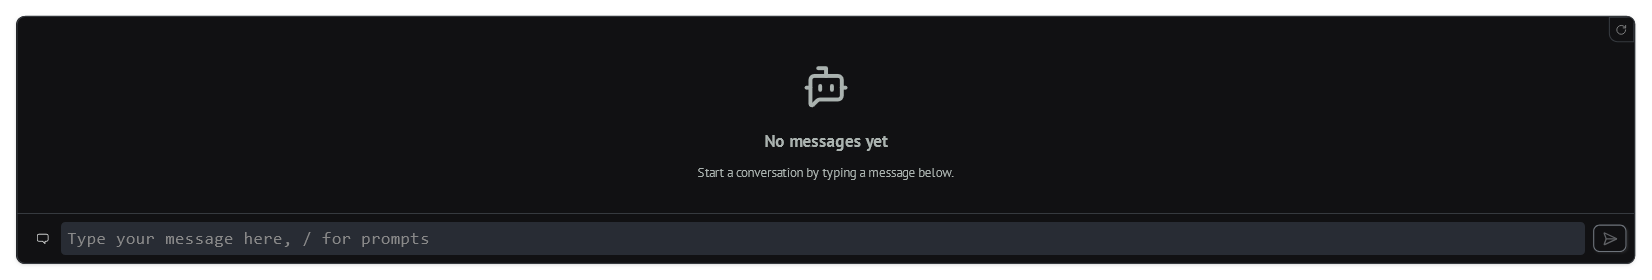

In [ ]:
interfaz_chat = mo.ui.chat(
    ejecutar_agente,
    prompts=[
        "Hola, ¿qué recuerdas de mí?",
        "Recuerda que estoy preparando un curso de agentes de IA para la CUGDL.",
        "¿Cuáles son mis proyectos actuales?",
        "Olvida todo lo que sabes sobre mis proyectos.",
        "Busca en internet: mejores prácticas para agentes LangGraph 2025.",
        "Explícame cómo funciona el middleware de resumen automático.",
        "Lista tus skills disponibles y explica cuándo usarías cada una.",
        "Instala la skill 'artifacts-builder' del marketplace.",
        "Delega en el investigador: estado del arte de agentes con skills en 2026.",
        'Genera un gráfico de barras con estos datos: [{"x": "a", "y": 3}, {"x": "b", "y": 7}]',
        "Consulta en el glosario del laboratorio qué es 'mcp'.",
        "Pide las estadísticas del curso al servidor laboratorio.",
    ],
    show_configuration_controls=False,
)
interfaz_chat

---
## 🧩 Panel de Skills (estándar agentskills.io)

Skills instaladas en `./skills/` — el mismo formato `SKILL.md` que usan
Claude Code y otros arneses. El agente ve solo los *frontmatter* al arrancar
y lee el contenido completo únicamente cuando la tarea lo requiere
(**progressive disclosure**). Instala desde el marketplace escribiendo un
nombre corto (`pdf`), una URL de carpeta GitHub o una URL raw a un `SKILL.md`.

*Nota: al instalar una skill o pulsar "Recargar", el agente se reconstruye
automáticamente para que DeepAgents relea `skills/`.*

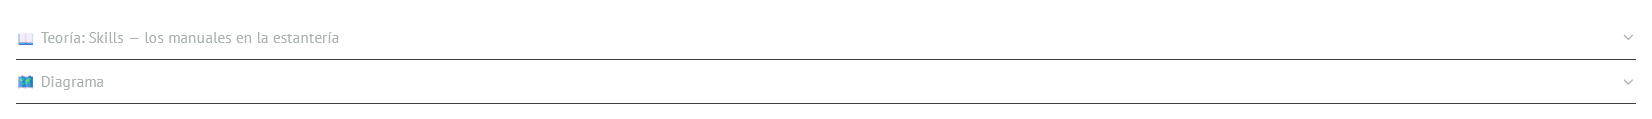

In [ ]:
mo.accordion(
    {
        "📖 Teoría: Skills — los manuales en la estantería": mo.md(
            r"""
Nadie memoriza el manual de la lavadora. Sabes que existe, sabes en qué estante está
y lo abres solo el día que parpadea un error raro. Una **skill** funciona igual para
el agente: es conocimiento que vive en una estantería y que el modelo consulta
únicamente cuando la tarea lo pide, sin cargar con él el resto del tiempo.

En concreto, una skill es una **carpeta** con un archivo `SKILL.md` dentro. Ese
archivo abre con un *frontmatter* YAML de dos campos obligatorios —`name` y
`description`— y sigue con instrucciones en markdown: procedimientos, criterios,
plantillas, ejemplos. Puede acompañarse de recursos opcionales (scripts, datos,
imágenes) en la misma carpeta. Y no es un formato casero: es el estándar
**agentskills.io**, el mismo que usan Claude Code y otros arneses, así que una skill
del marketplace se instala aquí sin traducir nada.

La pieza que hace que todo escale se llama **progressive disclosure** (revelación
progresiva). Cuando el agente arranca, no lee las skills enteras: lee **solo los
frontmatter**, es decir, el `name` y la `description` de cada una. Eso cuesta
poquísimos tokens. Con ese índice en la cabeza, el modelo decide sobre la marcha: si
la tarea encaja con alguna `description`, entonces —y solo entonces— hace `read_file`
del `SKILL.md` completo y sigue sus instrucciones. Si no encaja, no gasta ni un token
en ella. Gracias a eso puedes tener decenas de skills instaladas sin quemar la
ventana de contexto.

Conviene no confundir **skill** con **tool**, porque se parecen pero no son lo mismo.
Una tool es **código ejecutable**: una función de Python que el runtime corre. Una
skill es **conocimiento**: no ejecuta nada, guía al LLM sobre *cómo* pensar o *qué*
pasos seguir. La tool le da manos; la skill le da un manual de instrucciones.

Instalar es sencillo desde el Panel de Skills. Puedes dar tres cosas: un **nombre
corto** (p. ej. `pdf`) que el instalador resuelve contra el marketplace, una **URL de
carpeta** de GitHub (`.../tree/...`), o una **URL raw** directa a un `SKILL.md`. Un
detalle de seguridad que no se ve pero importa: el instalador **valida los nombres
derivados** de esas fuentes contra ataques de *path-traversal*, para que una URL
maliciosa no pueda escribir fuera de `./skills/`. Y como el agente solo lee la
estantería al construirse, cada vez que instalas una skill o pulsas **Recargar** el
notebook **reconstruye el agente** para que DeepAgents relea la carpeta `skills/`.

**Dónde verlo en este notebook:** abre el **🧩 Panel de Skills** para instalar desde
el marketplace y ver la tabla de skills disponibles; la tool **`instalar_skill`** es
la que descarga y valida cada fuente; y la carpeta **`./skills/`** en el proyecto es
la estantería física donde aterrizan los `SKILL.md`.
"""
        ),
        "🗺️ Diagrama": mo.mermaid(
            """
flowchart TD
A["🚀 Arranque del agente"] --> B["Lee SOLO los frontmatter:<br/>name + description de cada SKILL.md"]
B --> C{"¿La tarea encaja con<br/>alguna description?"}
C -->|"sí"| D["📖 read_file del<br/>SKILL.md completo"]
D --> E["Sigue las instrucciones<br/>+ usa los recursos de la carpeta"]
C -->|"no"| F["Responde sin skills<br/>(cero tokens gastados en ellas)"]
"""
        ),
    }
)

In [ ]:
ui_fuente_skill = mo.ui.text(
    placeholder="nombre corto · URL github.com/.../tree/... · URL raw SKILL.md",
    label="**Fuente de la skill**",
    full_width=True,
)
ui_boton_instalar = mo.ui.run_button(label="⬇️ Instalar skill")
ui_boton_recargar_skills = mo.ui.run_button(label="🔄 Recargar")

In [ ]:
obtener_version_skills, marcar_version_skills = mo.state(0)

In [ ]:
obtener_version_mcp, marcar_version_mcp = mo.state(0)

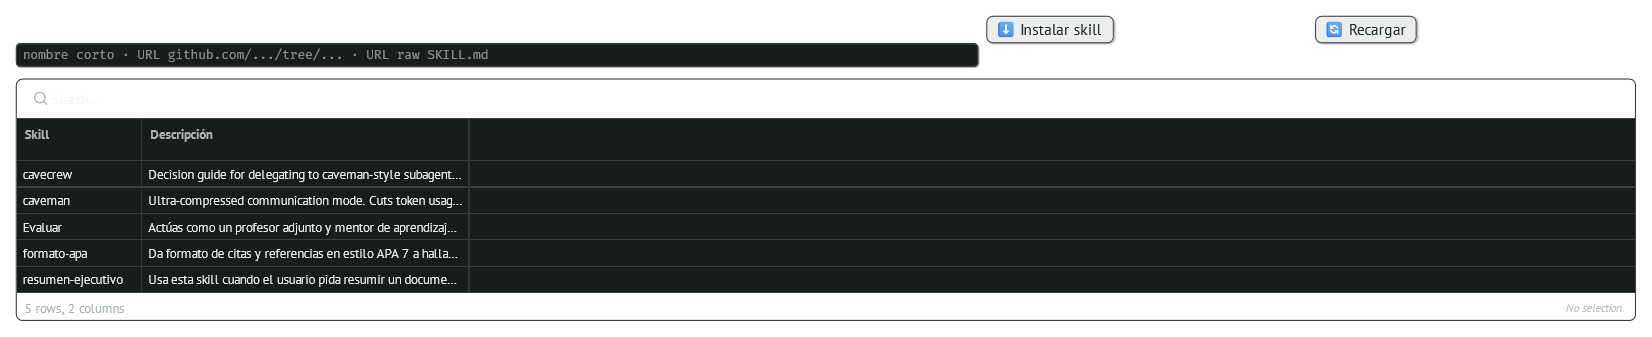

In [ ]:
if ui_boton_recargar_skills.value:
    marcar_version_skills(obtener_version_skills() + 1)

_msg_instalacion = ""
if ui_boton_instalar.value and ui_fuente_skill.value.strip():
    try:
        _msg_instalacion = ds.instalar_skill_desde_fuente(
            ui_fuente_skill.value.strip(), None, DIR_SKILLS
        )
        if _msg_instalacion.startswith("✅"):
            marcar_version_skills(obtener_version_skills() + 1)
    except Exception as _e:
        _msg_instalacion = f"❌ Error: {_e}"

_skills, _avisos_skills = ds.listar_skills(DIR_SKILLS)

_bloques = [
    mo.hstack(
        [ui_fuente_skill, ui_boton_instalar, ui_boton_recargar_skills],
        widths=[3, 1, 1],
    )
]
if _msg_instalacion:
    _bloques.append(
        mo.callout(
            mo.md(_msg_instalacion),
            kind="success"
            if _msg_instalacion.startswith("✅")
            else "danger",
        )
    )
for _aviso in _avisos_skills:
    _bloques.append(mo.callout(mo.md(_aviso), kind="warn"))
if _skills:
    _bloques.append(
        mo.ui.table(
            [
                {"Skill": s["name"], "Descripción": s["description"]}
                for s in _skills
            ],
            selection=None,
        )
    )
else:
    _bloques.append(
        mo.callout(
            mo.md("*(Sin skills — instala una arriba)*"), kind="info"
        )
    )

mo.vstack(_bloques)

---
## 🔌 Panel MCP — Servidores de Herramientas Externas

MCP (*Model Context Protocol*) es el **puerto USB-C de los agentes**: cualquier
servidor compatible enchufa sus tools al agente sin tocar el código del notebook.
La configuración vive en `./mcp_config.json` — el mismo formato que
`claude_desktop_config.json`, así que lo que aprendas aquí sirve para Claude
Desktop, Claude Code, Cursor y el resto del ecosistema.

> ⏳ *La primera conexión a un servidor `npx`/`uvx` puede tardar (descarga el
> paquete). El descubrimiento tiene un timeout de 15 s por servidor.*

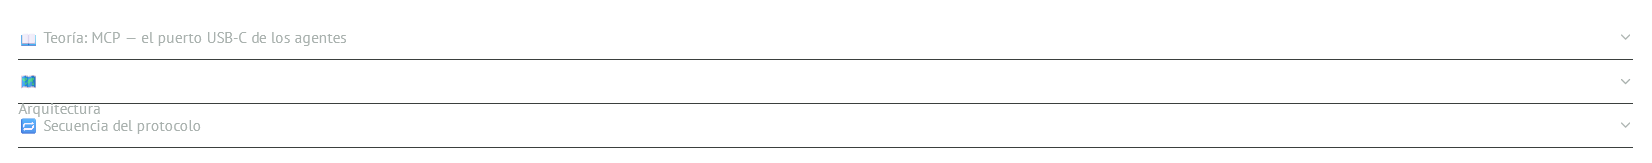

In [ ]:
mo.accordion(
    {
        "📖 Teoría: MCP — el puerto USB-C de los agentes": mo.md(
            r"""
Antes del USB-C, cada aparato traía su propio cargador con su propio conector, y
cambiar de móvil significaba cambiar de cable. Las tools nativas de un agente son eso:
**periféricos soldados a la placa**, integraciones hechas a mano una por una. **MCP**
(Model Context Protocol) es el **puerto estándar**: un conector único donde cualquier
fabricante enchufa su servicio sin tener que tocar la placa del agente.

El dolor que resuelve tiene nombre: el **problema N×M**. Si tienes N agentes que
quieren hablar con M servicios, y cada pareja necesita su propia integración a medida,
acabas con **N×M** piezas de pegamento que mantener. MCP lo reduce a **N+M**: cada
agente implementa **un** cliente del protocolo, cada servicio implementa **un**
servidor, y todos se entienden por el mismo estándar. La combinatoria se colapsa en
una suma.

La **arquitectura** tiene tres papeles. El **host** es este notebook. Dentro del host
viven los **clientes** —uno por cada servidor al que te conectas—. Y al otro lado
están los **servidores**, que pueden ser procesos **locales** (transporte `stdio`,
hablando por stdin/stdout) o **remotos** (transporte `http`/`sse`). ¿Qué anuncia un
servidor? Tres cosas: **tools** (acciones), **resources** (datos) y **prompts**
(plantillas).

El **ciclo de vida del protocolo** es un diálogo JSON-RPC en tres actos: `initialize`
(cliente y servidor negocian versión y capacidades), `tools/list` (el servidor entrega
su catálogo de tools con nombre, descripción y schema) y `tools/call` (el cliente
invoca una tool concreta y recibe el resultado). No hace falta que lo imagines:
**pulsa la Radiografía** del Panel MCP y verás esos mensajes en **bytes reales**, tal
cual cruzan el cable.

Nuestro **lado cliente** encaja en lo que ya sabes. El archivo `mcp_config.json`
—mismo formato que `claude_desktop_config.json`— declara qué servidores conectar.
`MultiServerMCPClient` los levanta, y las tools MCP entran al agente **como cualquier
`@tool`**: para el modelo son indistinguibles de las nativas. El parámetro
`tool_name_prefix` les pone un prefijo (verás las del laboratorio como `laboratorio_*`)
para **evitar colisiones** cuando dos servidores nombran igual una tool.

Nuestro **lado servidor** es para trastear: `servidor_mcp.py` está escrito con
**FastMCP**. Ábrelo, léelo, **añade una tool** y pulsa Recargar para verla aparecer. Es
la mejor forma de entender el protocolo: siendo el fabricante que enchufa algo nuevo.

Y para cerrar con honestidad, los **trade-offs**. Cada `tools/call` abre una **sesión
nueva** con el servidor, lo que añade algo de **latencia**. Los **subagentes** del
reparto usan solo tools nativas, no las de MCP. Y la **primera conexión** a un servidor
`npx`/`uvx` puede tardar, porque descarga el paquete antes de arrancar.

**Dónde verlo en este notebook:** abre el **🔌 Panel MCP** para ver el estado y el
formulario de servidores; pulsa la **Radiografía** para leer los mensajes JSON-RPC
crudos; inspecciona **`mcp_config.json`** y **`servidor_mcp.py`** para los dos lados
del protocolo; y en el **chat** llama a las tools **`laboratorio_*`** para invocar el
servidor demo de punta a punta.
"""
        ),
        "🗺️ Arquitectura": mo.mermaid(
            """
flowchart LR
subgraph HOST["🏠 Host — este notebook"]
    AG["🤖 Agente DeepAgents"]
    CL1["🔌 Cliente MCP 1"]
    CL2["🔌 Cliente MCP 2"]
    AG --- CL1
    AG --- CL2
end
CL1 <-->|"stdio · JSON-RPC<br/>por stdin/stdout"| S1["🧪 servidor_mcp.py<br/>(laboratorio local)"]
CL2 <-->|"http / sse"| S2["🌐 servidor remoto<br/>(de cualquier fabricante)"]
S1 --> T1["tools · resources · prompts"]
S2 --> T2["tools · resources · prompts"]
"""
        ),
        "🔁 Secuencia del protocolo": mo.mermaid(
            """
sequenceDiagram
participant C as 🔌 Cliente (notebook)
participant S as 🧪 Servidor (laboratorio)
C->>S: initialize (versión + capabilities)
S-->>C: sus capabilities (tengo tools y resources)
C->>S: notifications/initialized
C->>S: tools/list
S-->>C: catálogo: nombre + descripción + schema
Note over C: el agente ya "ve" las tools externas
C->>S: tools/call consultar_glosario {termino: "mcp"}
S-->>C: resultado (content blocks)
"""
        ),
    }
)

In [ ]:
ui_mcp_nombre = mo.ui.text(label="**Nombre**", placeholder="filesystem")
ui_mcp_transporte = mo.ui.dropdown(
    options=["stdio", "http", "sse"], value="stdio", label="**Transporte**"
)
ui_mcp_comando = mo.ui.text(
    label="**Comando** (stdio)", placeholder="npx · uvx · python"
)
ui_mcp_args = mo.ui.text_area(
    label="**Argumentos** (stdio) — uno por línea",
    placeholder="-y\n@modelcontextprotocol/server-filesystem\nD:/ruta/permitida",
    rows=3,
)
ui_mcp_url = mo.ui.text(
    label="**URL** (http/sse)", placeholder="http://localhost:8000/mcp"
)
ui_mcp_env = mo.ui.text_area(
    label="**Variables de entorno** — CLAVE=valor por línea (opcional)",
    placeholder="API_KEY=abc123",
    rows=2,
)
ui_boton_guardar_mcp = mo.ui.run_button(label="💾 Guardar servidor")
ui_mcp_eliminar = mo.ui.text(
    label="**Eliminar servidor** (nombre)", placeholder="filesystem"
)
ui_boton_eliminar_mcp = mo.ui.run_button(label="🗑️ Eliminar")
ui_boton_recargar_mcp = mo.ui.run_button(label="🔄 Recargar servidores")

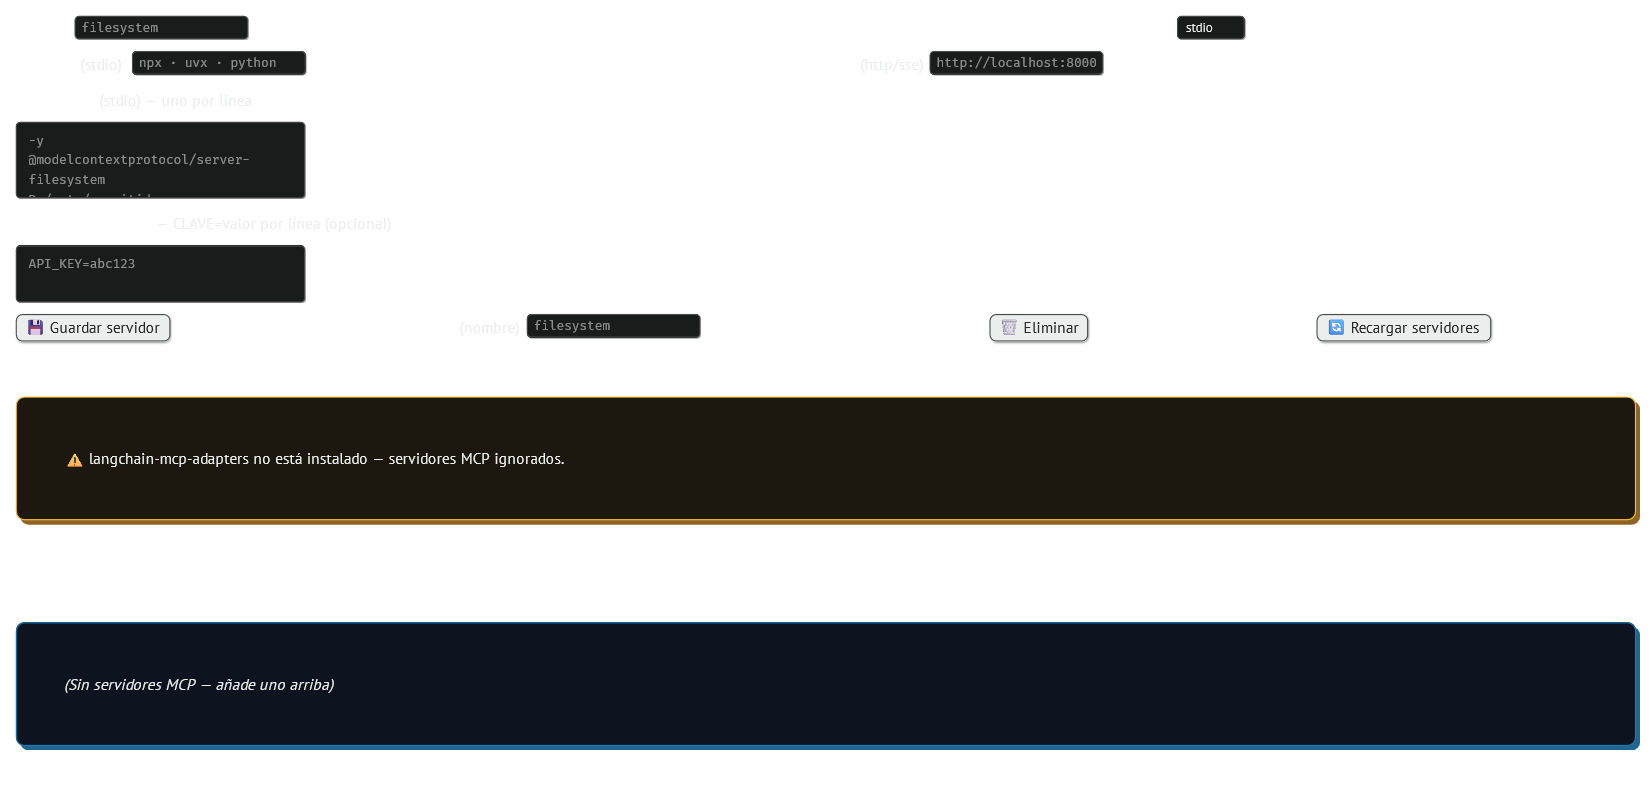

In [ ]:
if ui_boton_recargar_mcp.value:
    marcar_version_mcp(obtener_version_mcp() + 1)

_msg_mcp = ""
if ui_boton_guardar_mcp.value and not ui_mcp_nombre.value.strip():
    _msg_mcp = "❌ El nombre del servidor es obligatorio."
if ui_boton_guardar_mcp.value and ui_mcp_nombre.value.strip():
    _cfg = {"transport": ui_mcp_transporte.value, "enabled": True}
    if ui_mcp_transporte.value == "stdio":
        _cfg["command"] = ui_mcp_comando.value.strip()
        _cfg["args"] = [
            _l.strip()
            for _l in ui_mcp_args.value.splitlines()
            if _l.strip()
        ]
    else:
        _cfg["url"] = ui_mcp_url.value.strip()
    _env = ms.parsear_env(ui_mcp_env.value)
    if _env:
        _cfg["env"] = _env
    try:
        _msg_mcp = ms.agregar_servidor(
            RUTA_CONFIG_MCP, ui_mcp_nombre.value.strip(), _cfg
        )
        marcar_version_mcp(obtener_version_mcp() + 1)
    except ValueError as _e:
        _msg_mcp = f"❌ {_e}"

if ui_boton_eliminar_mcp.value and ui_mcp_eliminar.value.strip():
    try:
        if ms.eliminar_servidor(
            RUTA_CONFIG_MCP, ui_mcp_eliminar.value.strip()
        ):
            marcar_version_mcp(obtener_version_mcp() + 1)
            _msg_mcp = f"🗑️ Servidor '{ui_mcp_eliminar.value}' eliminado."
        else:
            _msg_mcp = f"❌ No existe '{ui_mcp_eliminar.value}'."
    except ValueError as _e:
        _msg_mcp = f"❌ {_e}"

_formulario = mo.vstack(
    [
        mo.hstack([ui_mcp_nombre, ui_mcp_transporte], widths=[2, 1]),
        mo.hstack([ui_mcp_comando, ui_mcp_url], widths=[1, 1]),
        ui_mcp_args,
        ui_mcp_env,
        mo.hstack(
            [
                ui_boton_guardar_mcp,
                ui_mcp_eliminar,
                ui_boton_eliminar_mcp,
                ui_boton_recargar_mcp,
            ],
            widths=[1, 2, 1, 1],
        ),
    ]
)

_bloques = [_formulario]
if _msg_mcp:
    _bloques.append(
        mo.callout(
            mo.md(_msg_mcp),
            kind="danger" if _msg_mcp.startswith("❌") else "success",
        )
    )
for _aviso in avisos_mcp:
    _bloques.append(mo.callout(mo.md(_aviso), kind="warn"))

if estado_mcp:
    _bloques.append(
        mo.ui.table(
            [
                {
                    "Servidor": _n,
                    "Estado": _e["estado"],
                    "Tools descubiertas": ", ".join(_e["tools"]) or "—",
                    "Detalle": _e["detalle"] or "—",
                }
                for _n, _e in estado_mcp.items()
            ],
            selection=None,
        )
    )
else:
    _bloques.append(
        mo.callout(
            mo.md("*(Sin servidores MCP — añade uno arriba)*"), kind="info"
        )
    )

mo.vstack(_bloques)

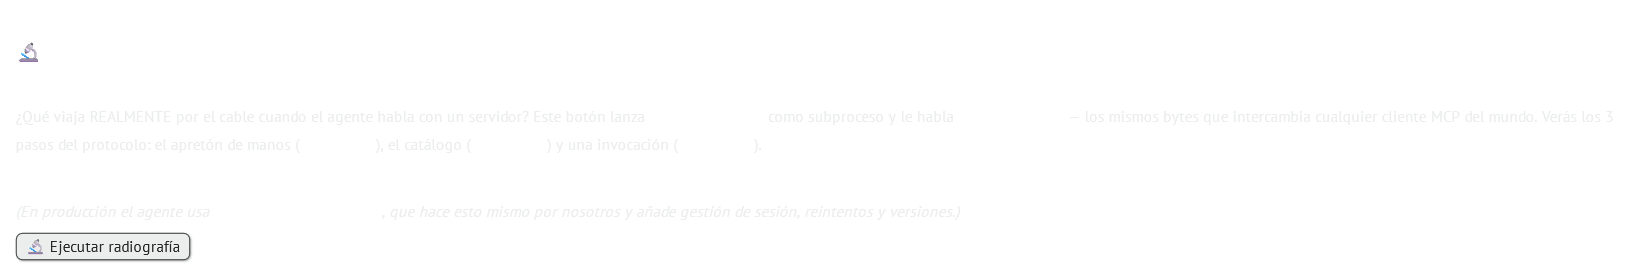

In [ ]:
ui_boton_radiografia = mo.ui.run_button(label="🔬 Ejecutar radiografía")
mo.vstack(
    [
        mo.md(r"""
### 🔬 Radiografía del protocolo MCP

¿Qué viaja REALMENTE por el cable cuando el agente habla con un servidor?
Este botón lanza `servidor_mcp.py` como subproceso y le habla **JSON-RPC
crudo** — los mismos bytes que intercambia cualquier cliente MCP del mundo.
Verás los 3 pasos del protocolo: el apretón de manos (`initialize`), el
catálogo (`tools/list`) y una invocación (`tools/call`).

*(En producción el agente usa `langchain-mcp-adapters`, que hace esto mismo
por nosotros y añade gestión de sesión, reintentos y versiones.)*
"""),
        ui_boton_radiografia,
    ]
)

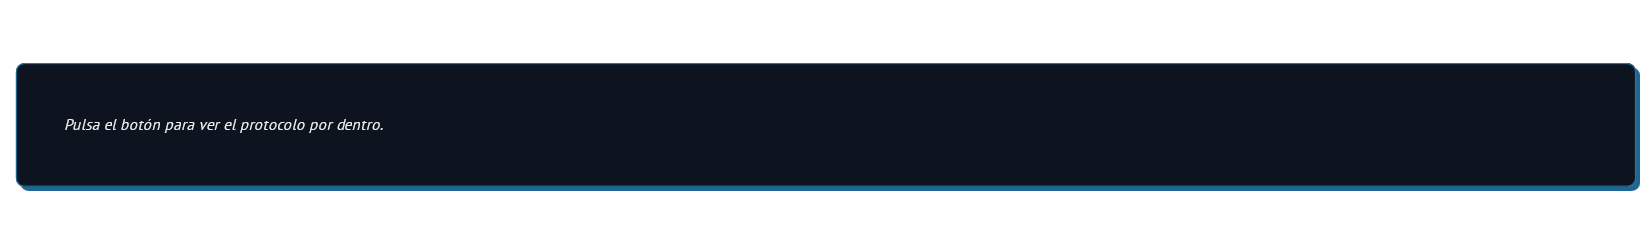

In [ ]:
_ANOTACIONES = {
    1: (
        "**Paso 1 · initialize — el apretón de manos.** Cliente y servidor "
        "negocian versión del protocolo y anuncian sus *capabilities* "
        "(tools, resources, prompts...). Nada funciona antes de esto."
    ),
    2: (
        "**Paso 2 · tools/list — el catálogo.** El servidor publica sus "
        "tools con nombre, descripción y JSON Schema de argumentos. Es "
        "EXACTAMENTE la información que el LLM usa para decidir invocarlas "
        "— compárala con los docstrings de `servidor_mcp.py`."
    ),
    3: (
        "**Paso 3 · tools/call — la invocación.** El cliente pide ejecutar "
        "`consultar_glosario(termino='mcp')` y el servidor devuelve el "
        "resultado como content blocks. Esto es lo que ocurre cada vez que "
        "el agente usa una tool MCP."
    ),
}

_salida = mo.callout(
    mo.md("*Pulsa el botón para ver el protocolo por dentro.*"),
    kind="info",
)
if ui_boton_radiografia.value:
    _peticiones = [
        {
            "jsonrpc": "2.0",
            "id": 1,
            "method": "initialize",
            "params": {
                "protocolVersion": "2025-03-26",
                "capabilities": {},
                "clientInfo": {"name": "radiografia-curso", "version": "1.0"},
            },
        },
        {"jsonrpc": "2.0", "method": "notifications/initialized"},
        {"jsonrpc": "2.0", "id": 2, "method": "tools/list"},
        {
            "jsonrpc": "2.0",
            "id": 3,
            "method": "tools/call",
            "params": {
                "name": "consultar_glosario",
                "arguments": {"termino": "mcp"},
            },
        },
    ]
    try:
        _respuestas = ms.dialogo_crudo_stdio(
            [sys.executable, str(RAIZ_PROYECTO / "servidor_mcp.py")],
            _peticiones,
            timeout=30.0,
        )
        _por_id = {r["id"]: r for r in _respuestas}
        _secciones = {}
        for _pet in _peticiones:
            if "id" not in _pet:
                continue  # la notificación no tiene respuesta
            _rid = _pet["id"]
            _resp = _por_id.get(_rid, {"(sin respuesta)": True})
            _titulo = f"Paso {_rid} · {_pet['method']}"
            _secciones[_titulo] = mo.vstack(
                [
                    mo.md(_ANOTACIONES[_rid]),
                    mo.hstack(
                        [
                            mo.vstack(
                                [
                                    mo.md("**→ Request (cliente):**"),
                                    mo.ui.code_editor(
                                        value=json.dumps(
                                            _pet, indent=2, ensure_ascii=False
                                        ),
                                        language="json",
                                        disabled=True,
                                    ),
                                ]
                            ),
                            mo.vstack(
                                [
                                    mo.md("**← Response (servidor):**"),
                                    mo.ui.code_editor(
                                        value=json.dumps(
                                            _resp, indent=2, ensure_ascii=False
                                        ),
                                        language="json",
                                        disabled=True,
                                    ),
                                ]
                            ),
                        ],
                        widths=[1, 1],
                    ),
                ]
            )
        _salida = mo.accordion(_secciones)
    except Exception as _e:
        _salida = mo.callout(
            mo.md(f"❌ Radiografía falló: `{_e!r}`"), kind="danger"
        )
_salida

---
## 🎭 El Reparto de la Obra — Constructor de Subagentes

Cada personaje es un archivo `./subagentes/<nombre>.md` (frontmatter YAML +
persona), el mismo formato que los *agents* de Claude Code. El **director**
(agente principal) lee las `description` y delega escenas vía la tool `task`.
Guardar o eliminar un personaje **reconstruye el agente al instante**.

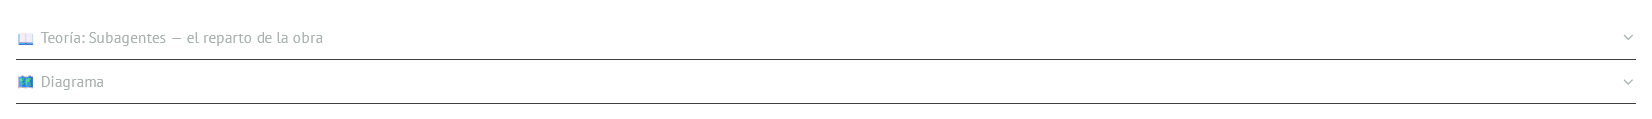

In [ ]:
mo.accordion(
    {
        "📖 Teoría: Subagentes — el reparto de la obra": mo.md(
            r"""
Un director de teatro no actúa todas las escenas. Tiene un **reparto**: lee la ficha
de cada actor, decide quién encaja en cada papel y le cede el escenario. El agente
principal de este notebook trabaja igual. Es el **director**, y no resuelve todo de su
puño: cuando una tarea encaja con un personaje, delega la escena vía la tool `task`.

Cada personaje del reparto vive en un archivo `./subagentes/<nombre>.md`. Ese archivo
tiene la misma estructura que ya conoces: un *frontmatter* con su nombre y su
`description`, y debajo su **persona** —el system prompt que define cómo piensa y
actúa—. Es el formato de *agents* de Claude Code, así que un personaje escrito aquí es
portable. El director lee las `description` de todo el reparto y, exactamente como
hacía con las skills, usa esa breve ficha para decidir a quién llamar.

Pero, ¿por qué molestarse en delegar en vez de hacerlo todo el director? La razón
técnica es el **aislamiento de contexto**. Cuando el director llama a
`task('investigador', encargo)`, el investigador arranca en un **contexto limpio
propio**: hace su trabajo —que puede ser leer cincuenta páginas web, comparar fuentes,
tomar notas— y devuelve al director **solo el resultado final**. Todo ese ruido
intermedio de la investigación **no contamina** la conversación del director. Sin
subagentes, esas cincuenta páginas se apilarían en la ventana del agente principal y
ahogarían el hilo. Con subagentes, el director recibe un resumen limpio y sigue fresco.

Hay más flexibilidad de la que parece. Cada personaje puede tener **su propio
subconjunto de tools** —no todas, solo las que su papel necesita— y hasta **su propio
modelo**: los alias estándar (`estandar`, `razonamiento`) se resuelven a objetos LLM
reales, así que puedes montar un personaje barato y rápido para tareas mecánicas y otro
más potente para razonar a fondo.

La regla práctica de cuándo delegar es intuitiva una vez la ves. Si la tarea es
**larga y autocontenida** —una investigación, una revisión exhaustiva, un trabajo que
genera mucho texto intermedio que no necesitas ver— dásela a un **personaje**. Si es
una **respuesta directa** que el director puede dar de un vistazo, no montes un reparto
para eso: contéstala tú. Delegar tiene un coste (arrancar un contexto nuevo), así que
se reserva para cuando el aislamiento compensa.

**Dónde verlo en este notebook:** abre el constructor **🎭 El Reparto de la Obra** para
crear y editar personajes; encontrarás **`investigador.md`** ya sembrado como ejemplo
listo para usar; y en el **chat** prueba el prompt *"Delega en el investigador..."*
para ver al director ceder el escenario y recibir de vuelta solo el resultado.
"""
        ),
        "🗺️ Diagrama": mo.mermaid(
            """
flowchart TD
DIR["🎬 Director<br/>(agente principal)"] -->|"task('investigador', encargo)"| S1["🕵️ investigador<br/>contexto limpio propio"]
DIR -->|"task(...)"| S2["✍️ tu próximo personaje"]
S1 -->|"SOLO el resultado final"| DIR
S2 -->|"SOLO el resultado final"| DIR
DIR --> R["💬 Respuesta integrada<br/>al usuario"]
"""
        ),
    }
)

In [ ]:
ui_sub_nombre = mo.ui.text(
    label="**Nombre** (sin espacios)", placeholder="critico"
)
ui_sub_descripcion = mo.ui.text(
    label="**Descripción** — el director la lee para decidir delegar",
    placeholder="Delega aquí revisiones de calidad de textos.",
    full_width=True,
)
ui_sub_persona = mo.ui.text_area(
    label="**Persona / system prompt del personaje**",
    placeholder="Eres un crítico literario implacable pero justo...",
    rows=6,
    full_width=True,
)
ui_sub_tools = mo.ui.multiselect(
    options=[t.name for t in herramientas_totales],
    label="**Tools del personaje**",
)
ui_sub_modelo = mo.ui.dropdown(
    options={
        "Heredar del director": "",
        "Estándar": "estandar",
        "Razonamiento": "razonamiento",
    },
    value="Heredar del director",
    label="**Modelo**",
)
ui_boton_guardar_sub = mo.ui.run_button(label="💾 Guardar personaje")
ui_sub_eliminar = mo.ui.text(
    label="**Eliminar personaje** (nombre)", placeholder="critico"
)
ui_boton_eliminar_sub = mo.ui.run_button(label="🗑️ Eliminar")

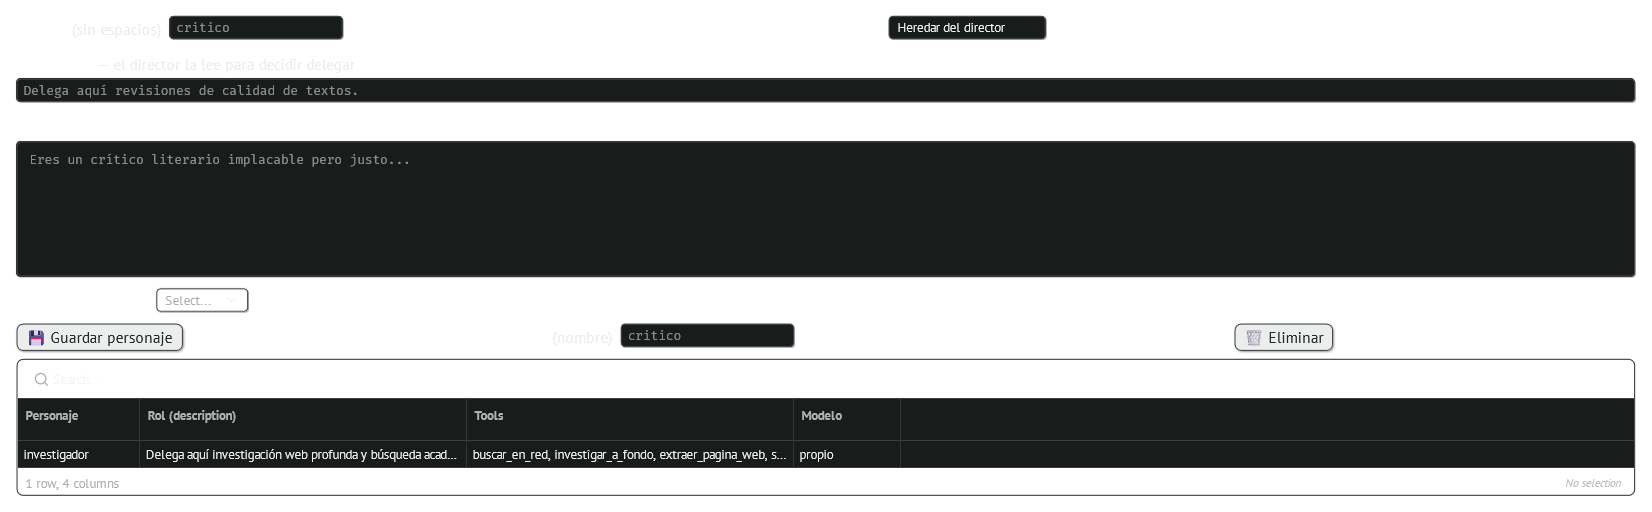

In [ ]:
_msg_reparto = ""
if ui_boton_guardar_sub.value:
    if ui_sub_nombre.value.strip() and ui_sub_persona.value.strip():
        try:
            ds.guardar_subagente_md(
                DIR_SUBAGENTES,
                name=ui_sub_nombre.value.strip(),
                description=ui_sub_descripcion.value.strip()
                or ui_sub_nombre.value,
                persona=ui_sub_persona.value,
                tools=list(ui_sub_tools.value),
                model=ui_sub_modelo.value or None,
            )
            marcar_version_reparto(obtener_version_reparto() + 1)
            _msg_reparto = f"✅ Personaje '{ui_sub_nombre.value}' guardado — agente reconstruido."
        except ValueError as _e:
            _msg_reparto = f"❌ {_e}"
    else:
        _msg_reparto = "❌ Nombre y persona son obligatorios."

if ui_boton_eliminar_sub.value and ui_sub_eliminar.value.strip():
    try:
        if ds.eliminar_subagente_md(
            DIR_SUBAGENTES, ui_sub_eliminar.value.strip()
        ):
            marcar_version_reparto(obtener_version_reparto() + 1)
            _msg_reparto = (
                f"🗑️ Personaje '{ui_sub_eliminar.value}' eliminado."
            )
        else:
            _msg_reparto = f"❌ No existe '{ui_sub_eliminar.value}'."
    except ValueError as _e:
        _msg_reparto = f"❌ {_e}"

_formulario = mo.vstack(
    [
        mo.hstack([ui_sub_nombre, ui_sub_modelo], widths=[1, 1]),
        ui_sub_descripcion,
        ui_sub_persona,
        ui_sub_tools,
        mo.hstack(
            [ui_boton_guardar_sub, ui_sub_eliminar, ui_boton_eliminar_sub],
            widths=[1, 2, 1],
        ),
    ]
)

_bloques = [_formulario]
if _msg_reparto:
    _bloques.append(
        mo.callout(
            mo.md(_msg_reparto),
            kind="danger" if _msg_reparto.startswith("❌") else "success",
        )
    )
for _aviso in avisos_subagentes:
    _bloques.append(mo.callout(mo.md(_aviso), kind="warn"))
if subagentes_cargados:
    _bloques.append(
        mo.ui.table(
            [
                {
                    "Personaje": s["name"],
                    "Rol (description)": s["description"],
                    "Tools": ", ".join(t.name for t in s["tools"]) or "—",
                    "Modelo": "propio" if "model" in s else "heredado",
                }
                for s in subagentes_cargados
            ],
            selection=None,
        )
    )
else:
    _bloques.append(mo.callout(mo.md("*(Reparto vacío)*"), kind="info"))

mo.vstack(_bloques)

---
## 🖼️ Galería de Artefactos Multimodales

Todo lo no-textual que produzcan las tools o el agente (vía `write_file`)
aterriza en `./artefactos/` y se renderiza aquí según su tipo:
imagen, PDF, video, audio, tabla, JSON, markdown, HTML o descarga directa.

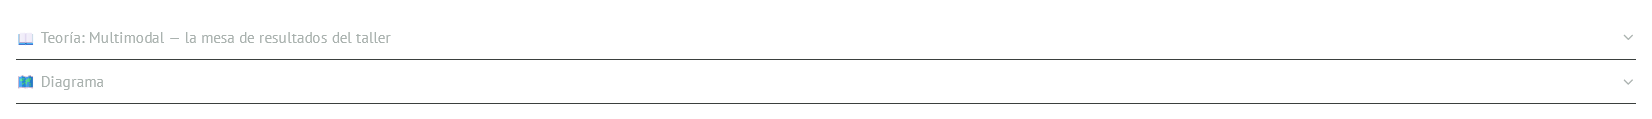

In [ ]:
mo.accordion(
    {
        "📖 Teoría: Multimodal — la mesa de resultados del taller": mo.md(
            r"""
En un buen taller, el artesano no te **describe** la silla que hizo: la pone sobre la
mesa de resultados para que la veas y la toques. El problema es que el LLM, por su
naturaleza, solo sabe **describir** —solo emite texto—. Entonces, ¿cómo logramos que
un agente te entregue una imagen, un PDF o un gráfico de verdad, y no un párrafo
hablando de ellos?

La respuesta es una **convención** sencilla y potente: toda tool que produzca algo
no-textual **lo escribe en `./artefactos/`** y devuelve, como texto, la **ruta** del
archivo. El LLM sigue haciendo lo único que sabe —emitir texto (la ruta)—, pero ese
texto es un puntero a un objeto real que vive en disco. La multimodalidad de
**salida** no está en el modelo; está en el acuerdo de dónde dejar las cosas.

Quien convierte esa ruta en algo visible es `clasificar_artefacto`, que decide **por
la extensión** qué tipo de artefacto es: imagen, pdf, video, audio, tabla, json, texto,
html u otro. Cada tipo tiene su render de marimo correspondiente —`mo.image`,
`mo.pdf`, `mo.video`, y así—, de modo que un `.png` se muestra como imagen y un `.pdf`
como documento paginado, sin que nadie tenga que decirlo explícitamente.

Esos artefactos aparecen en **dos vitrinas distintas**. La primera es la **Galería**:
el histórico completo de todo lo que se ha creado, refrescable a demanda. La segunda es
el **chat**, que usa un truco de *snapshot-diff*: toma una foto de la carpeta antes del
turno y otra después, y muestra **inline** solo lo que nació **durante** ese turno. Así
ves el resultado justo al lado de la respuesta que lo generó, sin bucear en la galería.

El ejemplo de punta a punta es `generar_grafico`. Sigue toda la cadena: recibe un
**JSON** de datos, lo carga en **Polars**, lo dibuja con **Altair**, exporta un **PNG**
a `./artefactos/`… y ese PNG aparece a la vez en la galería y, si lo pediste en el chat,
inline en la conversación. Un solo camino, del dato crudo a la imagen sobre la mesa.

Y no hace falta una tool a medida para cada cosa: el agente también puede crear
artefactos **directamente** con `write_file`, la herramienta de filesystem que trae
DeepAgents. Escribe en la **misma carpeta** `./artefactos/` y obtiene el **mismo
render**, porque la convención es la misma para todos. La mesa de resultados es una
sola, la use quien la use.

**Dónde verlo en este notebook:** abre la **🖼️ Galería de Artefactos Multimodales**
para ver el histórico renderizado por tipo; revisa la tool **`generar_grafico`** para
leer la cadena JSON → Polars → Altair → PNG; y en el **chat** pide un gráfico de barras
para ver el artefacto aparecer inline gracias al snapshot-diff.
"""
        ),
        "🗺️ Diagrama": mo.mermaid(
            """
flowchart LR
T["🔧 Tool<br/>(generar_grafico...)"] -->|"escribe archivo"| A[("📁 ./artefactos/")]
W["📝 write_file<br/>del agente"] -->|"escribe archivo"| A
A --> C{"clasificar_artefacto<br/>(por extensión)"}
C -->|"imagen · pdf · video<br/>audio · tabla · json..."| G["🖼️ Galería<br/>(histórico)"]
C -->|"creados en el turno<br/>(snapshot diff)"| CH["💬 Chat inline"]
"""
        ),
    }
)

In [ ]:
ui_boton_refrescar_galeria = mo.ui.run_button(label="🔄 Refrescar galería")
ui_limite_galeria = mo.ui.slider(
    start=5, stop=50, step=5, value=10, label="**Máx. artefactos**"
)

In [ ]:
_ = ui_boton_refrescar_galeria.value  # dependencia reactiva

_artefactos = ds.listar_artefactos(DIR_ARTEFACTOS, ui_limite_galeria.value)

_cabecera = mo.hstack(
    [ui_boton_refrescar_galeria, ui_limite_galeria], widths=[1, 2]
)
if _artefactos:
    _acordeon = mo.accordion(
        {
            (
                f"{_p.name} · {_p.stat().st_size / 1024:.1f} KB · "
                f"{datetime.datetime.fromtimestamp(_p.stat().st_mtime):%Y-%m-%d %H:%M}"
            ): render_artefacto(_p)
            for _p in _artefactos
        }
    )
    mo.vstack([_cabecera, _acordeon])
else:
    mo.vstack(
        [
            _cabecera,
            mo.callout(
                mo.md(
                    "*(Sin artefactos — pide al agente un gráfico para probar)*"
                ),
                kind="info",
            ),
        ]
    )

---
## 🗄️ Inspector de Memoria a Largo Plazo

Esta tabla muestra los hechos guardados en la base de datos de largo plazo.
Se actualiza conforme el agente guarda nuevos recuerdos — ya sea por llamada
explícita a `recordar` o por la reflexión autónoma post-turno.

In [ ]:
_memorias = almacen_memoria.recientes(ESPACIO_MEMORIA, 100)

if _memorias:
    mo.vstack(
        [
            mo.md(f"**{len(_memorias)} recuerdo(s) en la base de datos**"),
            mo.ui.table(
                [
                    {
                        "Categoría": m.get("kind", "—"),
                        "Hecho recordado": m.get("text", "—"),
                        "Guardado el": m.get("ts", "—"),
                    }
                    for m in _memorias
                ],
                selection=None,
            ),
        ]
    )
else:
    mo.callout(
        mo.md(
            "*(La base de datos de largo plazo está vacía — comienza una conversación)*"
        ),
        kind="info",
    )

---
## 🔍 Visor de Inyección de Memoria Dinámica

Aquí puedes observar exactamente qué recuerdos inyecta `@dynamic_prompt` en el
**system prompt** del agente para cualquier consulta de prueba.

Escribe una frase abajo y compara cómo cambia el contexto que ve el LLM según
el tema de la consulta — la misma base de datos, resultados distintos.
Así funciona la búsqueda **semántica + recencia** en la práctica.

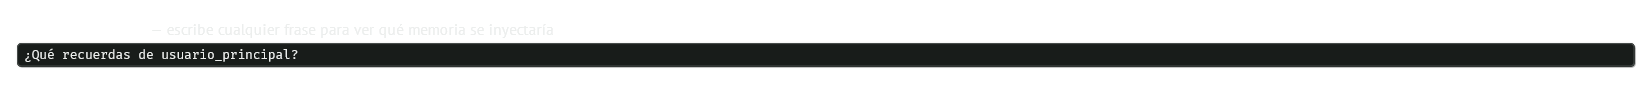

In [ ]:
ui_consulta_visor = mo.ui.text(
    value=f"¿Qué recuerdas de {ID_USUARIO}?",
    label="**Consulta de prueba** — escribe cualquier frase para ver qué memoria se inyectaría",
    full_width=True,
)
ui_consulta_visor

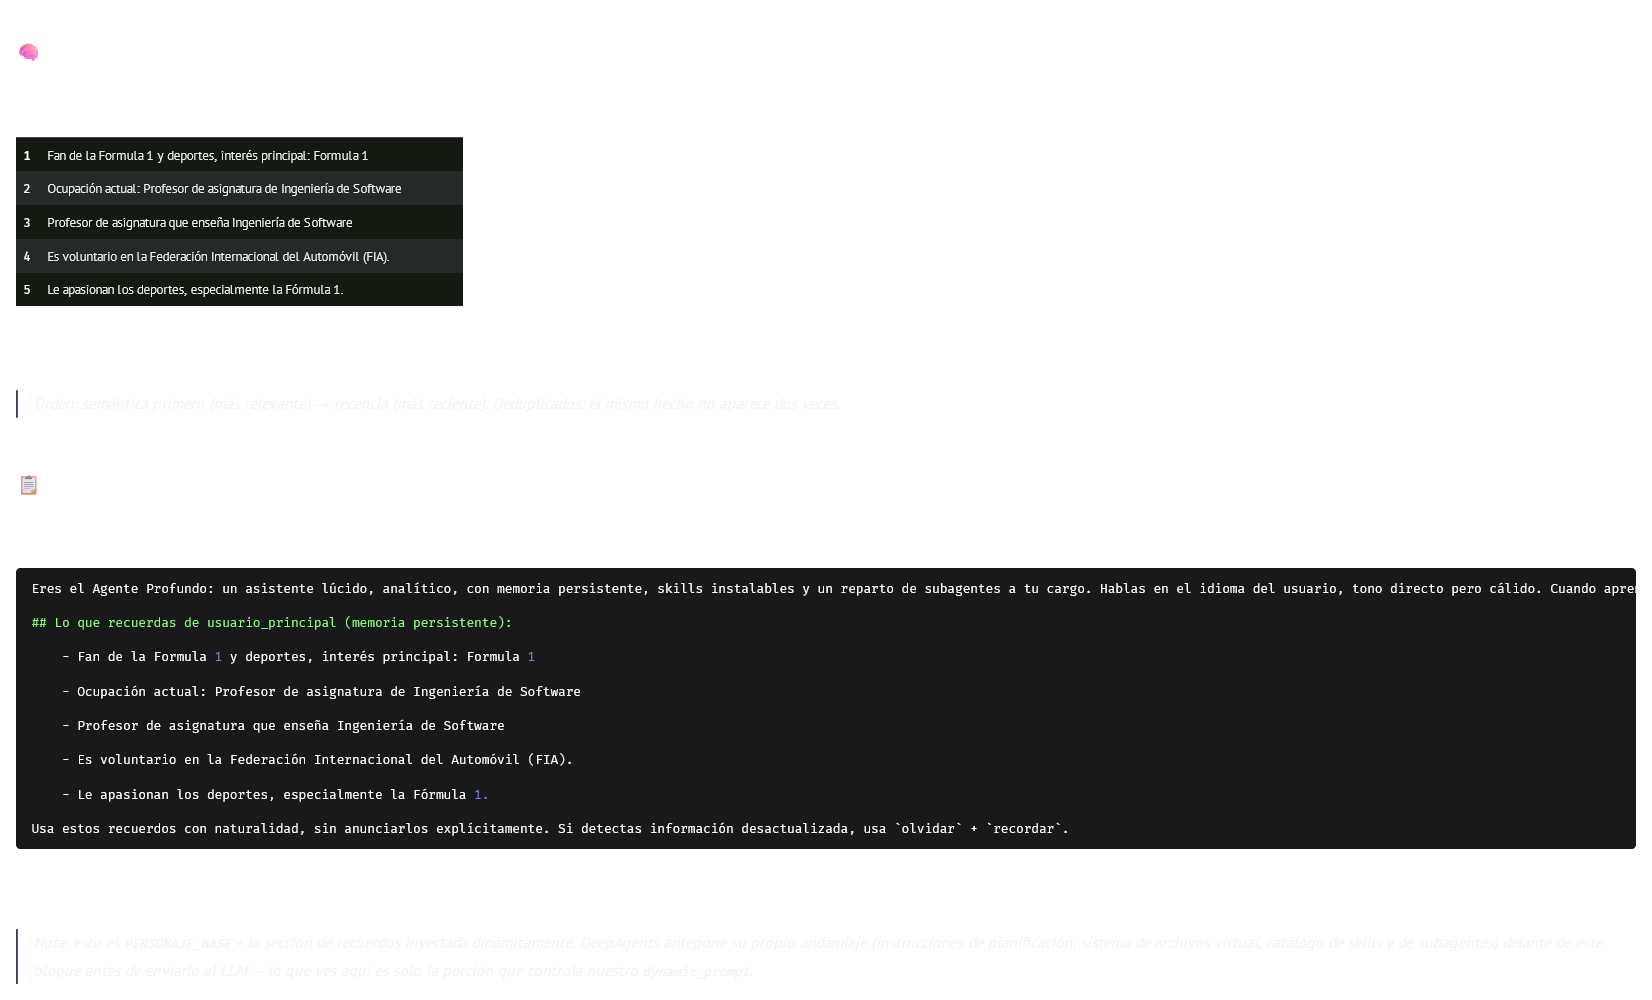

In [ ]:
_consulta = ui_consulta_visor.value.strip() or ID_USUARIO
_recuerdos = mezclar_recuerdos(_consulta)

# ── Panel 1: recuerdos recuperados ──────────────────────────────────────────────
if _recuerdos:
    _filas_mem = "\n".join(
        f"| `{i + 1}` | {r} |" for i, r in enumerate(_recuerdos)
    )
    _panel_mem = mo.md(f"""
### 🧠 Recuerdos recuperados para esta consulta ({len(_recuerdos)})

| # | Texto del recuerdo |
| :- | :--- |
{_filas_mem}

> *Orden: semántica primero (más relevante) → recencia (más reciente).
> Deduplicados: el mismo hecho no aparece dos veces.*
""")
else:
    _panel_mem = mo.callout(
        mo.md(
            "**Sin recuerdos aún.** Chatea con el agente para que guarde hechos y vuelve aquí."
        ),
        kind="info",
    )

# ── Panel 2: system prompt (PERSONAJE_BASE + recuerdos) que recibiría el LLM ────
if _recuerdos:
    _bloque = "\n".join(f"  - {t}" for t in _recuerdos)
    _system_prompt = (
        f"{PERSONAJE_BASE}\n\n"
        f"## Lo que recuerdas de {ID_USUARIO} (memoria persistente):\n"
        f"{_bloque}\n\n"
        "Usa estos recuerdos con naturalidad, sin anunciarlos explícitamente. "
        "Si detectas información desactualizada, usa `olvidar` + `recordar`."
    )
else:
    _system_prompt = (
        f"{PERSONAJE_BASE}\n\n"
        f"Aún no tienes recuerdos de {ID_USUARIO}. "
        "Cuando aprendas algo duradero en esta conversación, llama a `recordar`."
    )

_panel_prompt = mo.md(f"""
### 📋 System Prompt completo que ve el LLM

```
{_system_prompt}
```

> *Nota: esto es `PERSONAJE_BASE` + la sección de recuerdos inyectada dinámicamente.
> DeepAgents antepone su **propio andamiaje** (instrucciones de planificación,
> sistema de archivos virtual, catálogo de skills y de subagentes) delante de
> este bloque antes de enviarlo al LLM — lo que ves aquí es solo la porción
> que controla nuestro `dynamic_prompt`.*
""")

mo.vstack([_panel_mem, _panel_prompt], gap=2)

---
## 📊 Dashboard de Estado del Sistema

Telemetría en tiempo real: APIs activas, modelos configurados,
rutas de almacenamiento y pipeline de middlewares activo.

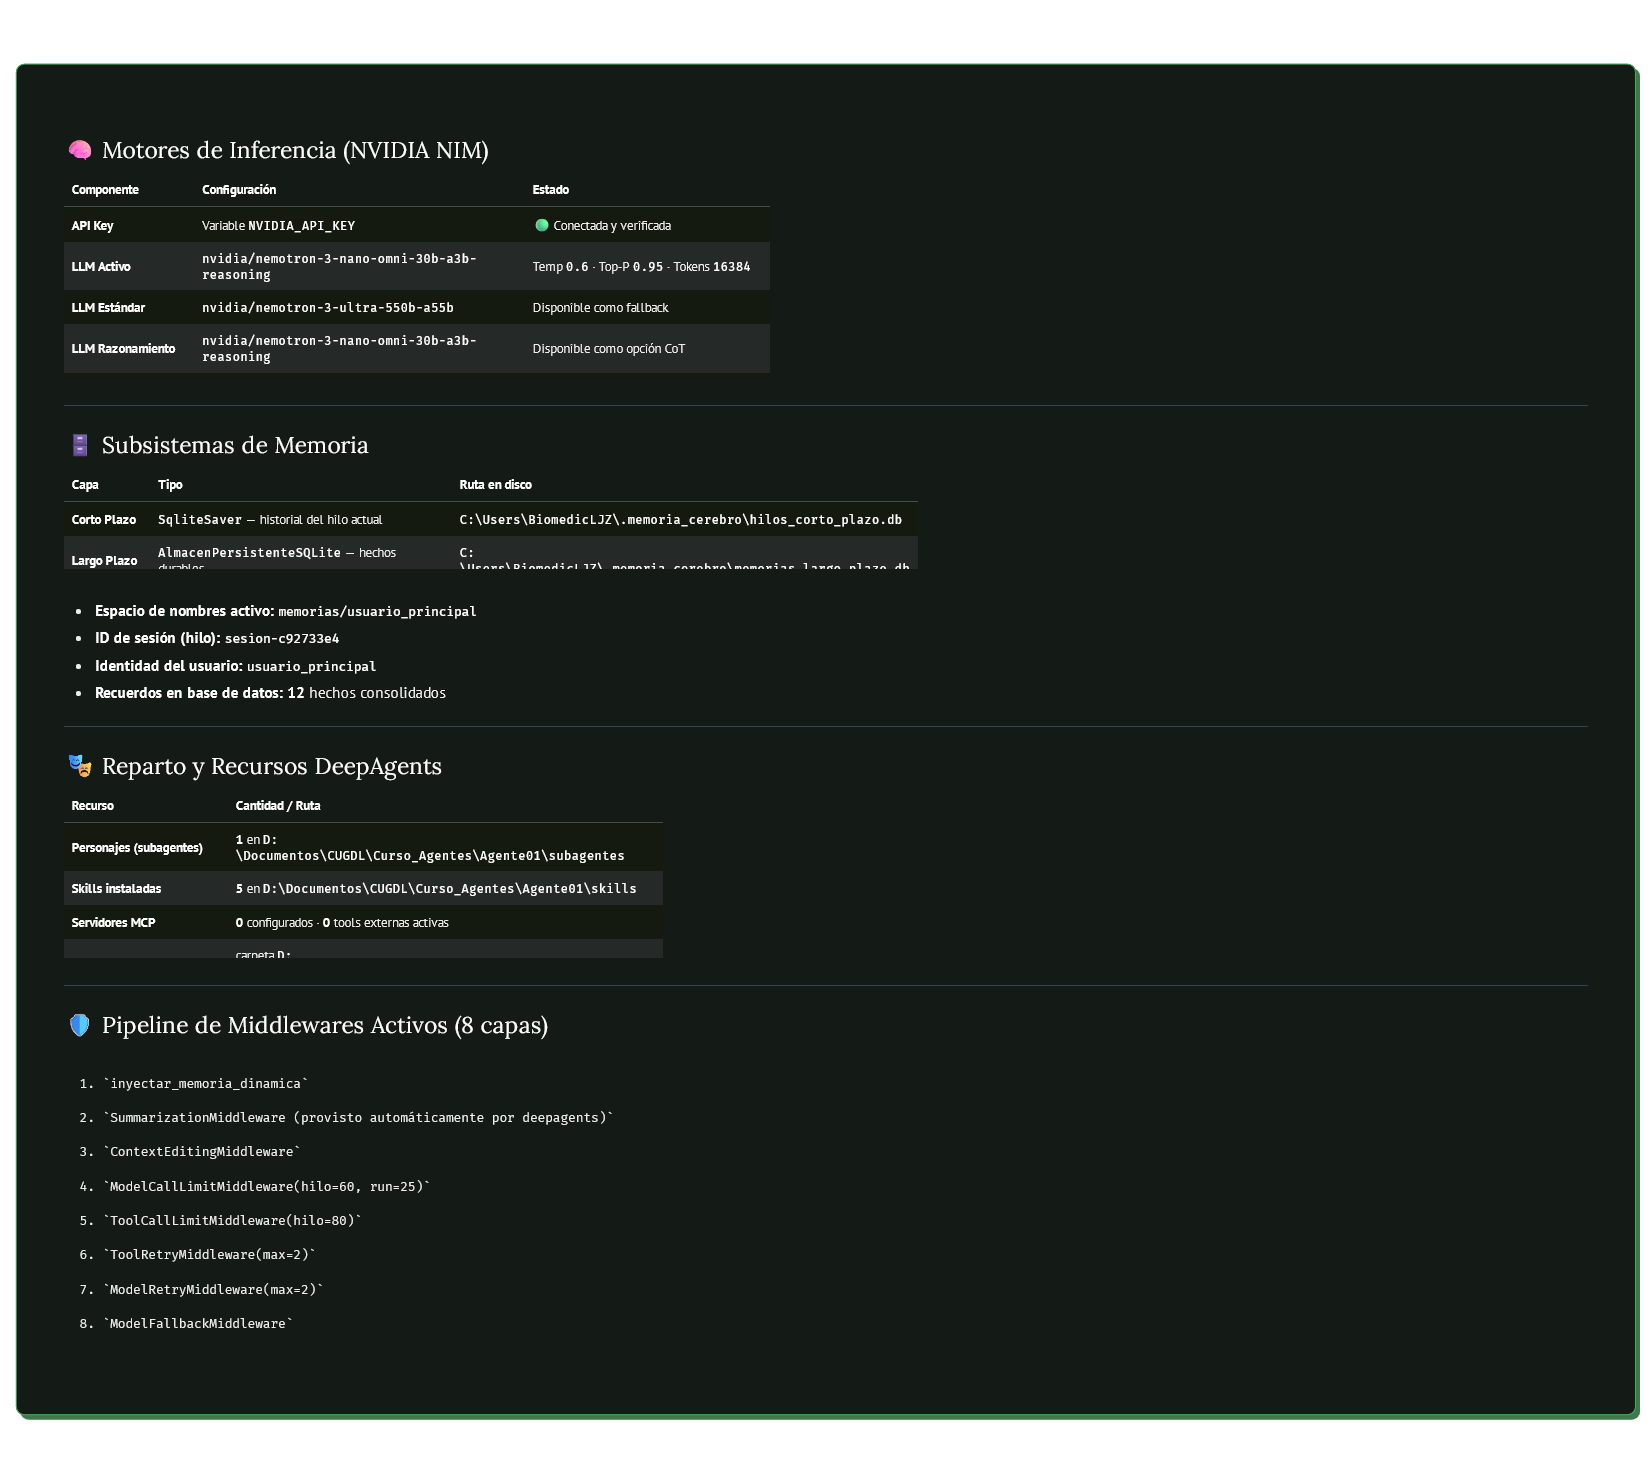

In [ ]:
_total_recuerdos = sum(len(v) for v in almacen_memoria._data.values())

_estado_api = (
    "🟢 Conectada y verificada"
    if PRESENCIA_API_NVIDIA
    else "🔴 **FALTANTE** — el agente está inactivo"
)
_dim_str = f"{DIMENSIONES_EMB} dimensiones" if DIMENSIONES_EMB else "—"
_estado_semantica = (
    f"🟢 Activa ({_dim_str})"
    if semantica_activa
    else "🔴 Degradada — solo recencia y keyword (sin NVIDIA_API_KEY o error de API)"
)

_lista_mw_dash = "\n".join(
    f"  {i + 1}. `{n}`" for i, n in enumerate(middlewares_nombres)
)

_num_skills = len(ds.listar_skills(DIR_SKILLS)[0])

_texto = f"""
## 🧠 Motores de Inferencia (NVIDIA NIM)

| Componente | Configuración | Estado |
| :--- | :--- | :--- |
| **API Key** | Variable `NVIDIA_API_KEY` | {_estado_api} |
| **LLM Activo** | `{nombre_modelo_activo}` | Temp `{ui_temperatura.value}` · Top-P `{ui_top_p.value}` · Tokens `{ui_max_tokens.value}` |
| **LLM Estándar** | `{MODELO_ESTANDAR}` | Disponible como fallback |
| **LLM Razonamiento** | `{MODELO_RAZONAMIENTO}` | Disponible como opción CoT |
| **Embeddings** | `{MODELO_EMBEDDINGS}` | {_estado_semantica} |

---

## 🗄️ Subsistemas de Memoria

| Capa | Tipo | Ruta en disco |
| :--- | :--- | :--- |
| **Corto Plazo** | `SqliteSaver` — historial del hilo actual | `{RUTA_BD_CORTO_PLAZO}` |
| **Largo Plazo** | `AlmacenPersistenteSQLite` — hechos durables | `{RUTA_BD_LARGO_PLAZO}` |

- **Espacio de nombres activo:** `{ESPACIO_MEMORIA[0]}/{ESPACIO_MEMORIA[1]}`
- **ID de sesión (hilo):** `{ID_HILO}`
- **Identidad del usuario:** `{ID_USUARIO}`
- **Recuerdos en base de datos:** **{_total_recuerdos}** hechos consolidados

---

## 🎭 Reparto y Recursos DeepAgents

| Recurso | Cantidad / Ruta |
| :--- | :--- |
| **Personajes (subagentes)** | **{len(subagentes_cargados)}** en `{DIR_SUBAGENTES}` |
| **Skills instaladas** | **{_num_skills}** en `{DIR_SKILLS}` |
| **Servidores MCP** | **{len(estado_mcp)}** configurados · **{len(tools_mcp)}** tools externas activas |
| **Artefactos multimodales** | carpeta `{DIR_ARTEFACTOS}` |

---

## 🛡️ Pipeline de Middlewares Activos ({len(middlewares_nombres)} capas)

{_lista_mw_dash}
""".strip()

_salud = (
    "success" if (PRESENCIA_API_NVIDIA and semantica_activa) else "danger"
)
mo.callout(mo.md(_texto), kind=_salud)

### 🛠️ Editor de Herramientas del Estudiante

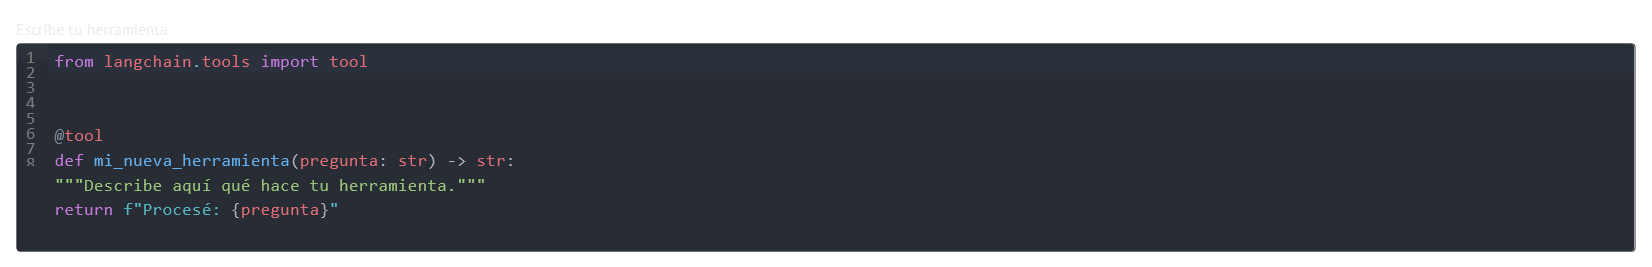

In [ ]:
editor_herramienta = mo.ui.code_editor(
    value='''from langchain.tools import tool


@tool
def mi_nueva_herramienta(pregunta: str) -> str:
"""Describe aquí qué hace tu herramienta."""
return f"Procesé: {pregunta}"
''',
    label="Escribe tu herramienta aquí:",
    language="python",
)
editor_herramienta

In [ ]:
namespace_herramientas = {}
try:
    # Ejecutamos el código del editor en un espacio seguro
    exec(editor_herramienta.value, globals(), namespace_herramientas)

    # Buscamos la función decorada con @tool
    herramienta_dinamica = [
        val
        for val in namespace_herramientas.values()
        if hasattr(val, "name") and val.name == "mi_nueva_herramienta"
    ][0]
    status_msg = "✅ Herramienta compilada y lista para el agente."
except Exception as e:
    herramienta_dinamica = None
    status_msg = f"❌ Error de sintaxis: {e}"

mo.md(status_msg)

<span class="markdown prose dark:prose-invert contents"><span class="paragraph">❌ Error de sintaxis: expected an indented block after function definition on line 5 (<string>, line 6)</span></span>

In [ ]:
if herramienta_dinamica:
    # Añadimos la herramienta nueva a la lista global
    herramientas_agente = herramientas_totales + [herramienta_dinamica]
else:
    herramientas_agente = herramientas_totales
# NOTA educativa: esta lista NO se inyecta automáticamente al agente vivo.
# Reconstruir el grafo DeepAgents en cada edición sería costoso; el patrón
# correcto (run_button + mo.state, como Skills/Reparto/MCP) queda como
# ejercicio para el estudiante.